In [485]:
#pip install tensorflow

In [486]:
# -------------------------------
# Import necessary libraries
# -------------------------------
import numpy as np  # Import NumPy for numerical operations
import pandas as pd  # Import Pandas for data manipulation
import tensorflow as tf  # Import TensorFlow for building neural network models
import seaborn as sns  # Import Seaborn for statistical plotting
import matplotlib.pyplot as plt  # Import Matplotlib for creating plots
from sklearn.model_selection import train_test_split  # Import train_test_split for splitting datasets
from sklearn.metrics import mean_squared_error, r2_score  # Import metrics for evaluating models
from sklearn.linear_model import LinearRegression, HuberRegressor, ElasticNet  # Import linear regression models
from sklearn.decomposition import PCA  # Import PCA for dimensionality reduction
from sklearn.cross_decomposition import PLSRegression  # Import PLSRegression for partial least squares regression
from sklearn.preprocessing import SplineTransformer  # Import SplineTransformer for spline feature transformation
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor  # Import ensemble regression models

In [487]:
plt.style.use('seaborn-v0_8-whitegrid')  # Set the plotting style to Seaborn whitegrid

# Project Overview: Forecasting Stock Returns with Machine Learning

This project investigates the potential of different machine learning models to predict excess stock returns using a combination of firm-specific characteristics and macroeconomic factors. The data is synthetically generated to simulate a realistic asset pricing environment, where interactions between stock-level and macro-level variables drive returns.

We implement a wide range of models, including:
- traditional linear regressions (OLS, WLS, Huber),
- regularized approaches (ElasticNet),
- dimension reduction methods (PCR, PLS),
- generalized linear models with spline transformations,
- nonlinear learners (Random Forest, Gradient Boosting, Neural Networks).

Models are assessed using multiple evaluation strategies:
- **Out-of-sample $R^2$** as a measure of explanatory power,
- **Diebold–Mariano test statistics** for relative forecast accuracy,
- **Feature importance** via R² drop and squared deviation analysis,
- **Decile portfolio analysis** to evaluate return ranking and Sharpe ratios.

This comprehensive approach helps to identify which models are best suited for return forecasting, understand how they use available information, and evaluate their usefulness in constructing profitable long–short investment strategies.


---
---
###  Synthetic Data Generation

We simulate a panel of stock returns and predictors to evaluate forecasting models. The setup includes $N = 10$ stocks observed over $T = 24$ time periods. Each stock has $K = 5$ stock-specific characteristics, and each time period is associated with $M = 3$ macroeconomic factors.

For each stock $i$ and time $t$, we construct interaction terms between macro factors and stock characteristics via an outer product, resulting in $K \times M$ features $z_{it}$. The excess return $r_{i,t+1}$ is then generated as a linear function of $z_{it}$ plus Gaussian noise:

$$
r_{i,t+1} = z_{it}^\top \theta + \varepsilon_{it}, \quad \varepsilon_{it} \sim \mathcal{N}(0, 0.2^2)
$$

This yields a balanced panel of predictors and returns, which is flattened into a cross-sectional time-series format for model training and evaluation.


In [488]:
# -------------------------------
# Part 1: Data Generation
# -------------------------------
n_stocks = 10  # Define the number of stocks
n_months = 24  # Define the number of months (time periods)
n_characteristics = 5  # Define the number of stock-specific characteristics
n_macro_factors = 3  # Define the number of macroeconomic factors

np.random.seed(42)  # Set the random seed for reproducibility
stock_characteristics = np.random.rand(n_stocks, n_months, n_characteristics)  # Generate random stock characteristic data
macro_factors = np.random.rand(n_months, n_macro_factors)  # Generate random macroeconomic factor data

zi_t = np.zeros((n_stocks, n_months, n_characteristics * n_macro_factors))

for t in range(n_months):
    for i in range(n_stocks):
        zi_t[i,t] = np.outer(macro_factors[t], stock_characteristics[i,t]).flatten()

theta = np.random.rand(n_characteristics * n_macro_factors)
ri_t_plus_1 = np.zeros((n_stocks, n_months))

for t in range(n_months):
    for i in range(n_stocks):
        ri_t_plus_1[i,t] = zi_t[i,t].dot(theta) + np.random.normal(0, 0.2)

zi_t_flattened = zi_t.reshape(n_stocks * n_months, -1)

ri_t_flattened = ri_t_plus_1.flatten()

zi_t_df = pd.DataFrame(zi_t_flattened, columns=[f"z_{k + 1}" for k in range(zi_t_flattened.shape[1])])
zi_t_df["Stock_ID"] = np.repeat(range(1, n_stocks + 1), n_months)
zi_t_df["Month"] = np.tile(range(1, n_months + 1), n_stocks)

ri_t_df = pd.DataFrame({
    "Stock_ID" : np.repeat(range(1, n_stocks + 1), n_months),
    "Month" : np.tile(range(1, n_months + 1), n_stocks),
    "Excess_Return" : ri_t_flattened
})

combined_data = pd.concat([zi_t_df,ri_t_df["Excess_Return"]], axis=1)

In [489]:
combined_data.head()

,z_1,z_2,z_3,z_4,z_5,z_6,z_7,z_8,z_9,z_10,z_11,z_12,z_13,z_14,z_15,Stock_ID,Month,Excess_Return
0,0.284000,0.720892,0.555044,0.453941,0.118303,0.009209,0.023375,0.017997,0.014719,0.003836,0.008286,0.021033,0.016194,0.013244,0.003452,1,1,0.589649
1,0.050481,0.018796,0.280303,0.194527,0.229140,0.076226,0.028382,0.423251,0.293731,0.345995,0.120179,0.044748,0.667309,0.463103,0.545504,1,2,1.594037
2,0.014065,0.662735,0.568804,0.145090,0.124240,0.009179,0.432485,0.371188,0.094683,0.081076,0.005632,0.265393,0.227779,0.058102,0.049752,1,3,0.802150
3,0.182877,0.303367,0.523247,0.430703,0.290392,0.078164,0.129662,0.223641,0.184087,0.124116,0.082786,0.137331,0.236868,0.194974,0.131457,1,4,1.760188
4,0.100114,0.022825,0.047802,0.059946,0.074624,0.486307,0.110871,0.232199,0.291188,0.362489,0.424431,0.096764,0.202656,0.254139,0.316368,1,5,1.822977


---
---
###  Train–Validation–Test Split

We partition the synthetic dataset into training, validation, and test subsets. First, 30% of the full data is held out as the test set. The remaining 70% is split again, with approximately 28.57% used for validation (i.e., 20% of the full sample), leaving 50% for training.

This results in three mutually exclusive datasets used for model training, hyperparameter tuning, and out-of-sample performance evaluation.


In [490]:
# -------------------------------
# Part 2: Train–Validation–Test Split
# -------------------------------
X = combined_data[[col for col in combined_data.columns if col.startswith('z_')]]
y = combined_data["Excess_Return"]

X_train_val , X_test , y_train_val , y_test = train_test_split(zi_t_flattened, ri_t_flattened, test_size=0.3, random_state=42)
X_train , X_val , y_train , y_val = train_test_split(X_train_val, y_train_val, test_size=0.2857, random_state=42)

---
---

### Model Training

### OLS Regression

Ordinary Least Squares (OLS) is a fundamental linear regression technique that estimates the vector of coefficients $\beta$ by minimizing the sum of squared differences between observed outcomes and predicted values. Formally, the model assumes:

$$
y = X\beta + \varepsilon, \quad \varepsilon \sim \mathcal{N}(0, \sigma^2 I)
$$

where $X$ is the matrix of predictors, $y$ is the response vector, and $\varepsilon$ represents random error.

OLS provides unbiased and efficient estimates under the classical Gauss-Markov assumptions. It is particularly well-suited when the relationship between predictors and the outcome is approximately linear, the predictors are not highly correlated (i.e., no multicollinearity), and the error terms are homoscedastic and independent.

Due to its simplicity, closed-form solution, and interpretability, OLS is often used as a benchmark model in predictive tasks.


In [491]:
# --- OLS Regression ---
ols_model = LinearRegression()
ols_model.fit(X_train,y_train)

y_pred_ols = ols_model.predict(X_test)

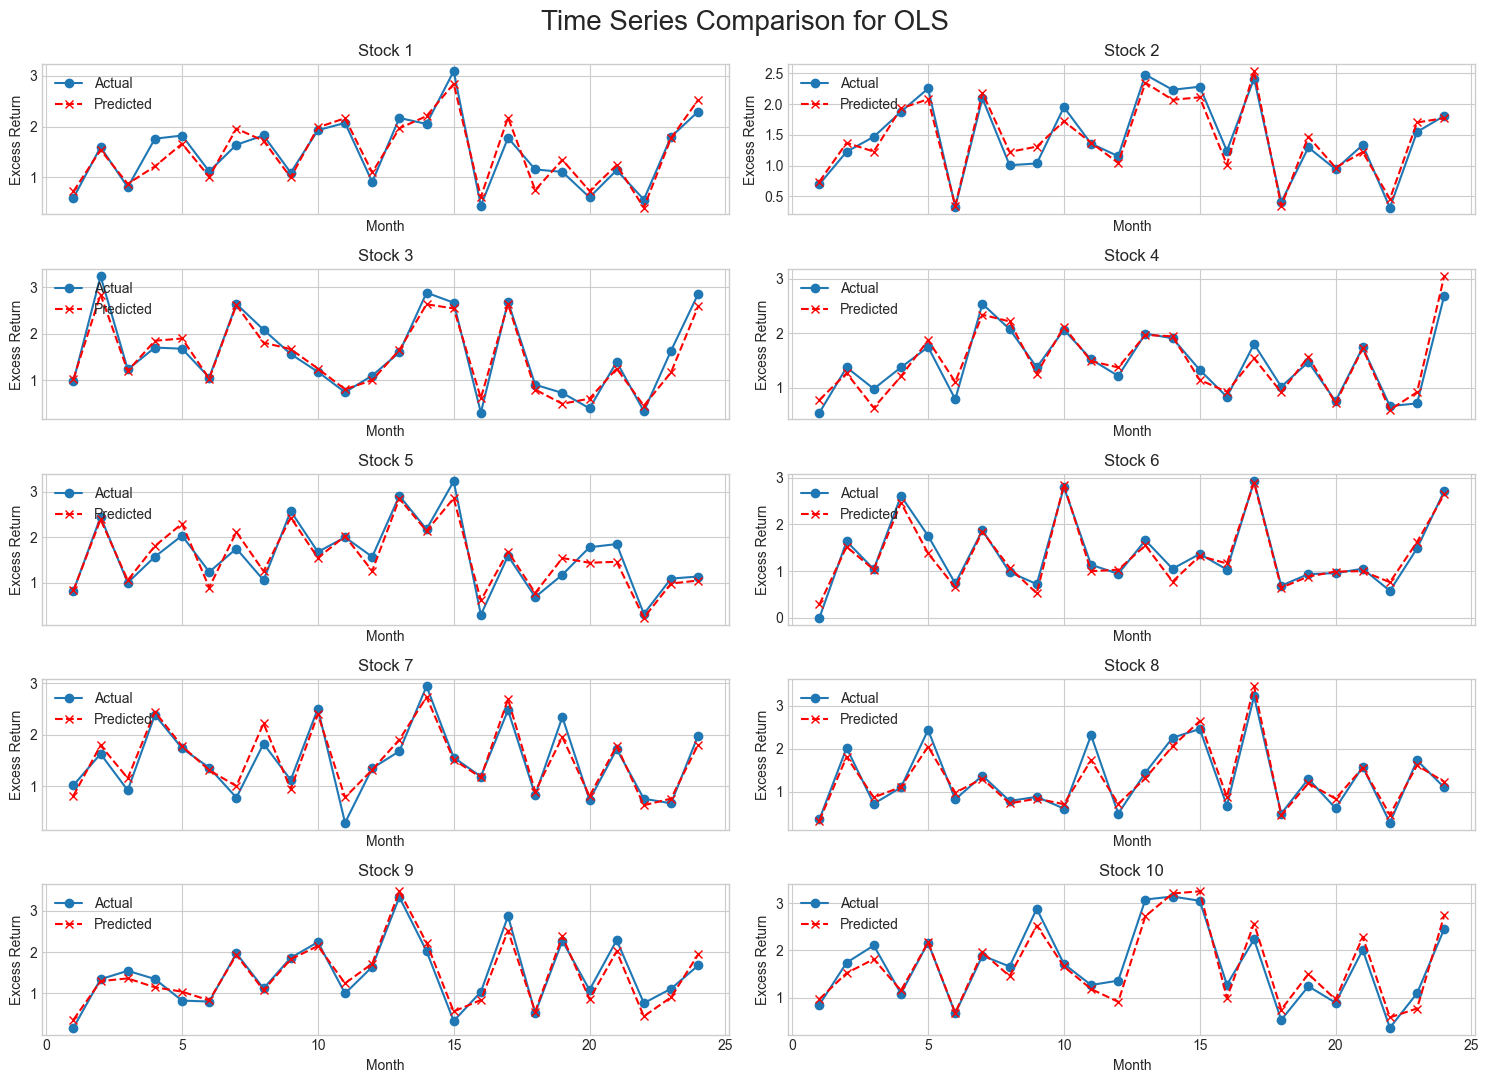

In [492]:
# --- OLS Regression for all observations ---
X_all = X.to_numpy()
y_pred_ols_all = ols_model.predict(X_all)

fig, axes = plt.subplots(5, 2, sharex=True, figsize=(15, 11))
axes = axes.flatten()
fig.suptitle("Time Series Comparison for OLS", fontsize=20)

for i, stock_id in enumerate(sorted(combined_data['Stock_ID'].unique())):
    df_s = combined_data[combined_data['Stock_ID'] == stock_id].sort_values('Month')
    idx = df_s.index
    axes[i].plot(
        df_s['Month'], df_s['Excess_Return'],
        marker='o', linestyle='-', label='Actual'
    )
    axes[i].plot(
        df_s['Month'], y_pred_ols_all[idx],
        marker='x', linestyle='--', color='red', label='Predicted'
    )
    axes[i].set_title(f"Stock {stock_id}")
    axes[i].set_xlabel("Month")
    axes[i].set_ylabel("Excess Return")
    axes[i].legend(loc='upper left')

plt.tight_layout()
plt.show()

### Weighted Least Squares (WLS)

Weighted Least Squares (WLS) is a generalization of Ordinary Least Squares that accounts for **heteroskedasticity**—situations where the variance of the error terms varies across observations. WLS assigns a weight $w_i$ to each data point, giving more influence to observations with lower variance.

The model minimizes a **weighted** sum of squared errors:

$$
\min_\beta \sum_{i=1}^{n} w_i (y_i - x_i^\top \beta)^2
$$

The solution is given by the weighted normal equations:

$$
\hat{\beta}_{\text{WLS}} = (X^\top W X)^{-1} X^\top W y
$$

where $W$ is a diagonal matrix of observation weights.

WLS is especially useful when residual variances are known or can be estimated, such as in time series with volatility clustering or panels with known group-level variability. It improves efficiency of the estimates by addressing non-constant error variance, making it more reliable than OLS under heteroskedasticity.


In [493]:
# --- Weighted Linear Regression ---
class WeightedLinearRegression:
    """
    Implements weighted ordinary least squares regression using the normal equations.
    Observations are weighted by the provided sample weights.
    """
    def __init__(self):
        # theta will hold the fitted coefficient vector (P×1)
        self.theta = None

    def fit(self, X, y, weights):
        """
        Fit the weighted least squares model.
        
        Parameters:
        X       : ndarray of shape (N, P)
                  Design matrix of predictors.
        y       : ndarray of shape (N,)
                  Target vector of responses.
        weights : ndarray of shape (N,)
                  Sample weights for each observation.
        """
        # Construct the diagonal weight matrix W
        W = np.diag(weights)
        # Compute θ = (Xᵀ W X)^(-1) Xᵀ W y
        self.theta = np.linalg.inv(X.T @ W @ X) @ (X.T @ W @ y)

    def predict(self, X):
        """
        Predict responses for new data using the fitted coefficients.
        
        Parameters:
        X : ndarray of shape (M, P)
            New design matrix.
        
        Returns:
        y_pred : ndarray of shape (M,)
                 Predicted responses.
        """
        return X @ self.theta


In [494]:
# create DataFrame with features, target, and weights
data = pd.DataFrame(zi_t_flattened, columns=[f"z_{k + 1}" for k in range(zi_t_flattened.shape[1])])
data["Excess_Return"] = ri_t_flattened
data["weights"] = np.random.rand(n_stocks * n_months)

# split into train and test (preserving weights)
train_data, test_data = train_test_split(data, test_size=0.3, random_state=42)

# extract predictor matrix, target vector, and sample weights
X_train = train_data.drop(columns=["Excess_Return", "weights"]).values
y_train = train_data["Excess_Return"].values
w_train = train_data["weights"].values

X_test  = test_data.drop(columns=["Excess_Return", "weights"]).values
y_test  = test_data["Excess_Return"].values
w_test  = test_data["weights"].values

# fit weighted least squares and predict
wls = WeightedLinearRegression()
wls.fit(X_train, y_train, w_train)
y_pred_wls = wls.predict(X_test)

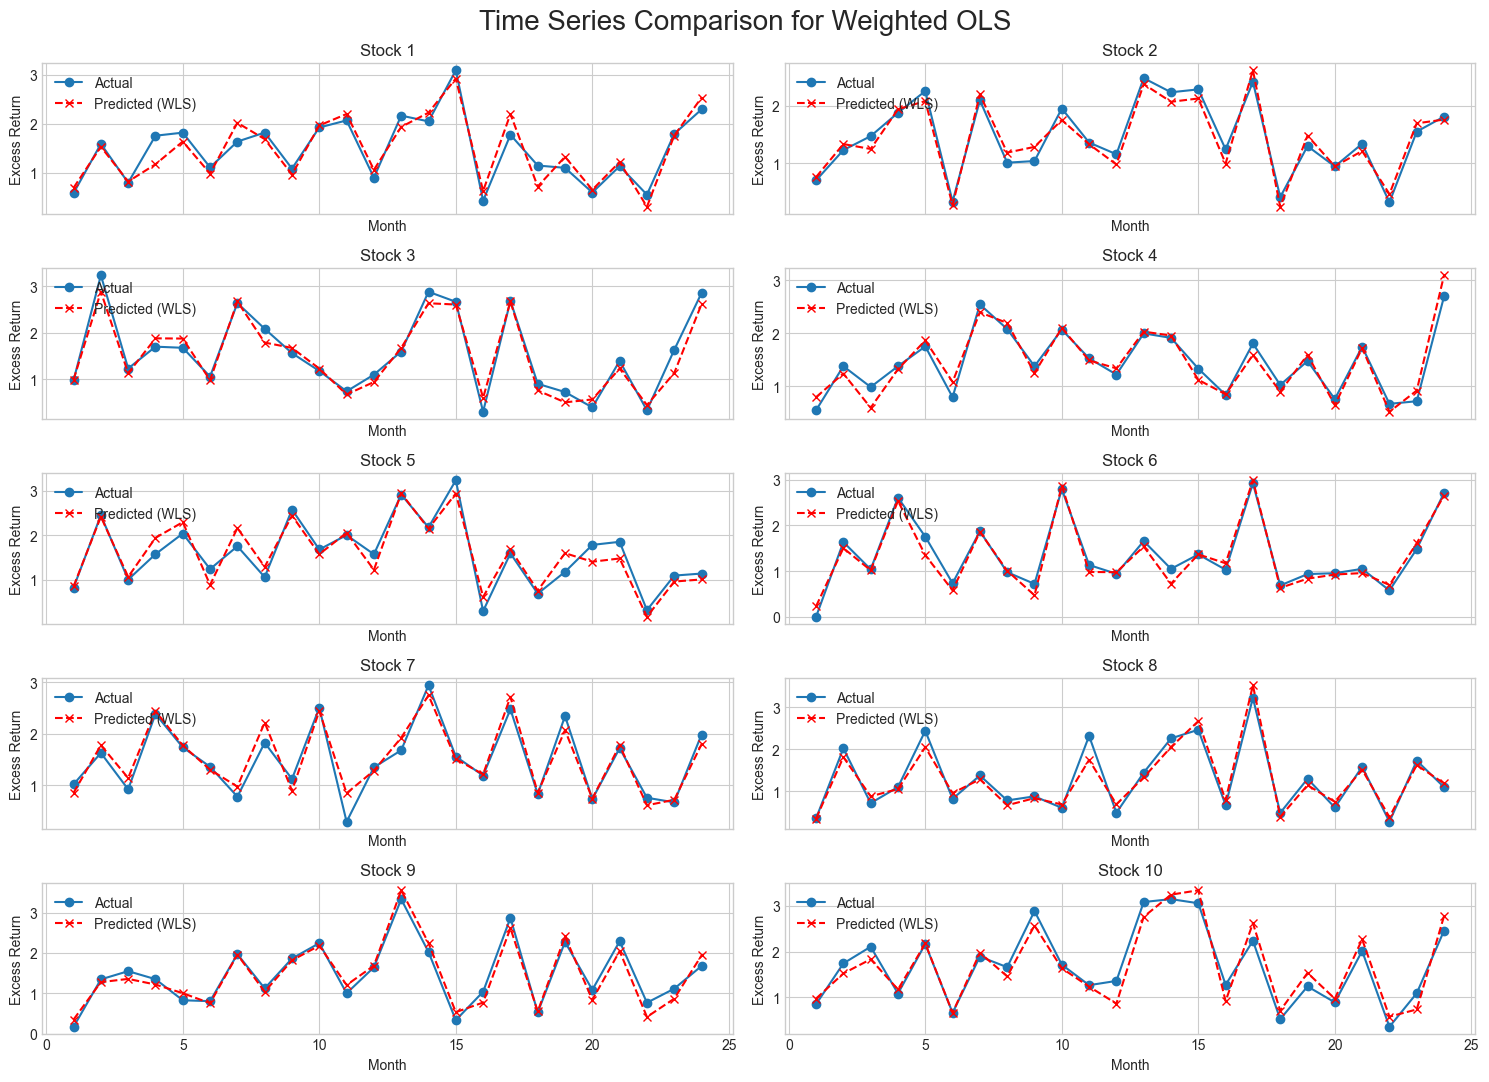

In [495]:
# compute WLS predictions for all observations
y_pred_wls_all = wls.predict(X_all)

# plot actual vs. weighted‐OLS predicted per stock using y_pred_wls_all
fig, axes = plt.subplots(5, 2, sharex=True, figsize=(15, 11))
axes = axes.flatten()
fig.suptitle("Time Series Comparison for Weighted OLS", fontsize=20)

for i, stock_id in enumerate(sorted(combined_data['Stock_ID'].unique())):
    df_s = combined_data[combined_data['Stock_ID'] == stock_id].sort_values('Month')
    idx  = df_s.index  # get original indices for this stock
    
    axes[i].plot(
        df_s['Month'], df_s['Excess_Return'],
        marker='o', linestyle='-', label='Actual'
    )
    axes[i].plot(
        df_s['Month'], y_pred_wls_all[idx],
        marker='x', linestyle='--', color='red', label='Predicted (WLS)'
    )
    axes[i].set_title(f"Stock {stock_id}")
    axes[i].set_xlabel("Month")
    axes[i].set_ylabel("Excess Return")
    axes[i].legend(loc='upper left')

plt.tight_layout()
plt.show()


### Huber Regressor

The Huber Regressor is a **robust linear model** designed to handle outliers in the response variable. It combines the squared loss (used in OLS) for small residuals with absolute loss for large residuals, reducing the influence of extreme values.

The Huber loss function is defined as:

$$
L_\delta(r) =
\begin{cases}
\frac{1}{2} r^2 & \text{for } |r| \leq \delta \\
\delta (|r| - \frac{1}{2} \delta) & \text{for } |r| > \delta
\end{cases}
$$

where $r = y_i - x_i^\top \beta$ is the residual and $\delta$ is a user-defined threshold parameter.

By interpolating between least squares and least absolute deviations, the Huber Regressor maintains **high efficiency under Gaussian noise**, while being **robust to outliers**. It is particularly useful when the data contains occasional large errors that would unduly influence standard OLS estimates.


In [496]:
# --- Huber Regressor ---
huber_model = HuberRegressor()
huber_model.fit(X_train, y_train)

y_pred_huber = huber_model.predict(X_test)

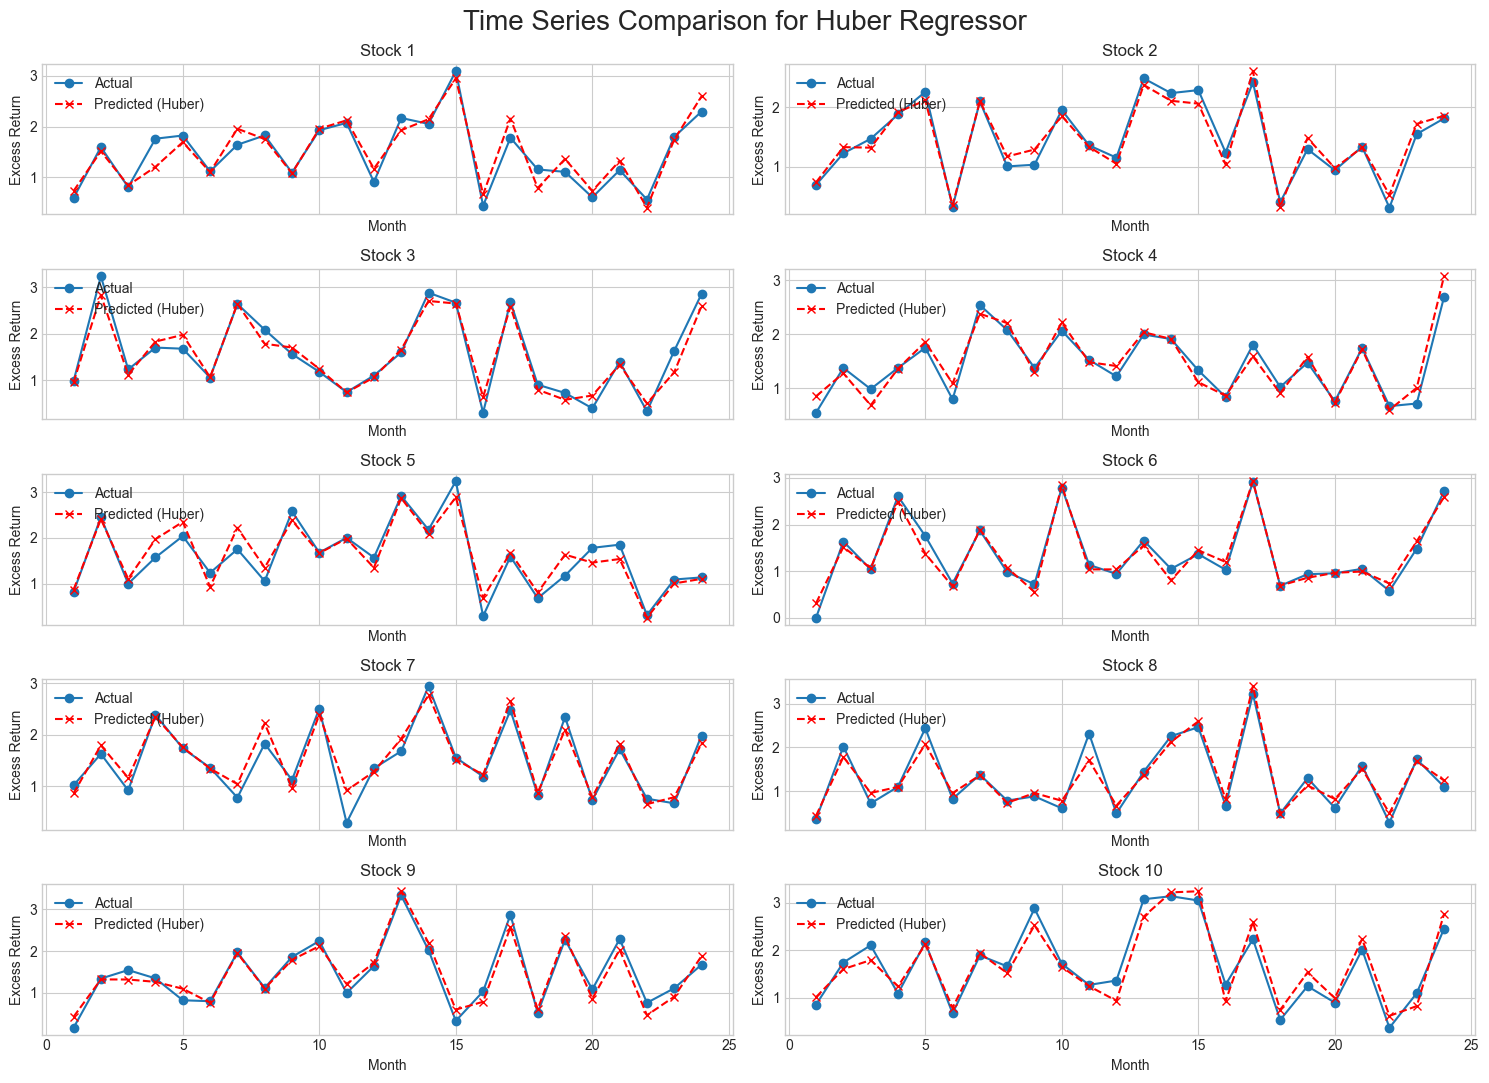

In [497]:
# compute Huber predictions for all observations
y_pred_huber_all = huber_model.predict(X_all)

# plot actual vs. Huber predicted per stock using y_pred_huber_all
fig, axes = plt.subplots(5, 2, sharex=True, figsize=(15, 11))
axes = axes.flatten()
fig.suptitle("Time Series Comparison for Huber Regressor", fontsize=20)

for i, stock_id in enumerate(sorted(combined_data['Stock_ID'].unique())):
    df_s = combined_data[combined_data['Stock_ID'] == stock_id].sort_values('Month')
    idx  = df_s.index  # original indices for this stock
    
    # actual returns
    axes[i].plot(
        df_s['Month'], df_s['Excess_Return'],
        marker='o', linestyle='-', label='Actual'
    )
    # Huber predictions
    axes[i].plot(
        df_s['Month'], y_pred_huber_all[idx],
        marker='x', linestyle='--', color='red', label='Predicted (Huber)'
    )
    axes[i].set_title(f"Stock {stock_id}")
    axes[i].set_xlabel("Month")
    axes[i].set_ylabel("Excess Return")
    axes[i].legend(loc='upper left')

plt.tight_layout()
plt.show()


### ElasticNet Regression

ElasticNet is a **regularized linear regression model** that combines both L1 (Lasso) and L2 (Ridge) penalties. It addresses the limitations of Lasso when dealing with highly correlated features by introducing a balance between feature selection and coefficient shrinkage.

The optimization objective is:

$$
\min_\beta \left\{ \frac{1}{2n} \sum_{i=1}^{n} (y_i - x_i^\top \beta)^2 + \alpha \left[ \, \lambda \|\beta\|_1 + \frac{1 - \lambda}{2} \|\beta\|_2^2 \, \right] \right\}
$$

where:
- $\alpha$ controls the overall strength of regularization
- $\lambda$ (or `l1_ratio`) balances L1 and L2 penalties

ElasticNet is well-suited for datasets with **many correlated predictors** and **high-dimensional settings**, where it performs variable selection and stabilizes the solution simultaneously.

In this implementation, we tune the model using a grid search over $\alpha$ and `l1_ratio`, selecting the combination that minimizes validation mean squared error. The final model is refit on the combined training and validation data.


In [498]:
# --- ElasticNet Model Tuning ---
best_enet = {"mse":np.inf}
for alpha in [0.01,0.1,1,10]:
    for l1_ratio in [0.1,0.5,0.9]:
        en = ElasticNet(alpha=alpha,l1_ratio=l1_ratio,max_iter=1000,random_state=42)
        en.fit(X_train,y_train)
        mse = mean_squared_error(y_val,en.predict(X_val))
        if mse < best_enet['mse']:
            best_enet.update({"mse":mse,"alpha":alpha,"l1_ratio":l1_ratio})
            
enet = ElasticNet(alpha=best_enet['alpha'],l1_ratio=best_enet['l1_ratio'],max_iter=5000,random_state=42)
enet.fit(np.vstack([X_train,X_val]),np.concatenate([y_train,y_val]))

y_pred_enet = enet.predict(X_test)

In [499]:
# --- ElasticNet Model Tuning ---
# We perform a manual grid search over regularization strength (alpha) and L1/L2 mixing (l1_ratio)
# to minimize validation MSE.
best_enet = {"mse": np.inf}

for alpha in [0.01, 0.1, 1, 10]:
    for l1_ratio in [0.1, 0.5, 0.9]:
        # alpha controls overall regularization strength
        # l1_ratio determines the mix between L1 (lasso) and L2 (ridge)
        en = ElasticNet(
            alpha=alpha,
            l1_ratio=l1_ratio,
            max_iter=1000,      
            random_state=42
        )
        en.fit(X_train, y_train)  # fit on training set
        mse = mean_squared_error(y_val, en.predict(X_val))  # evaluate on validation set
        if mse < best_enet["mse"]:
            best_enet.update({
                "mse": mse,
                "alpha": alpha,
                "l1_ratio": l1_ratio
            })

enet = ElasticNet(
    alpha=best_enet["alpha"],
    l1_ratio=best_enet["l1_ratio"],
    max_iter=1000,
    random_state=42
)
enet.fit(
    np.vstack([X_train, X_val]),
    np.concatenate([y_train, y_val])
)

# Generate predictions on the test set
y_pred_enet = enet.predict(X_test)

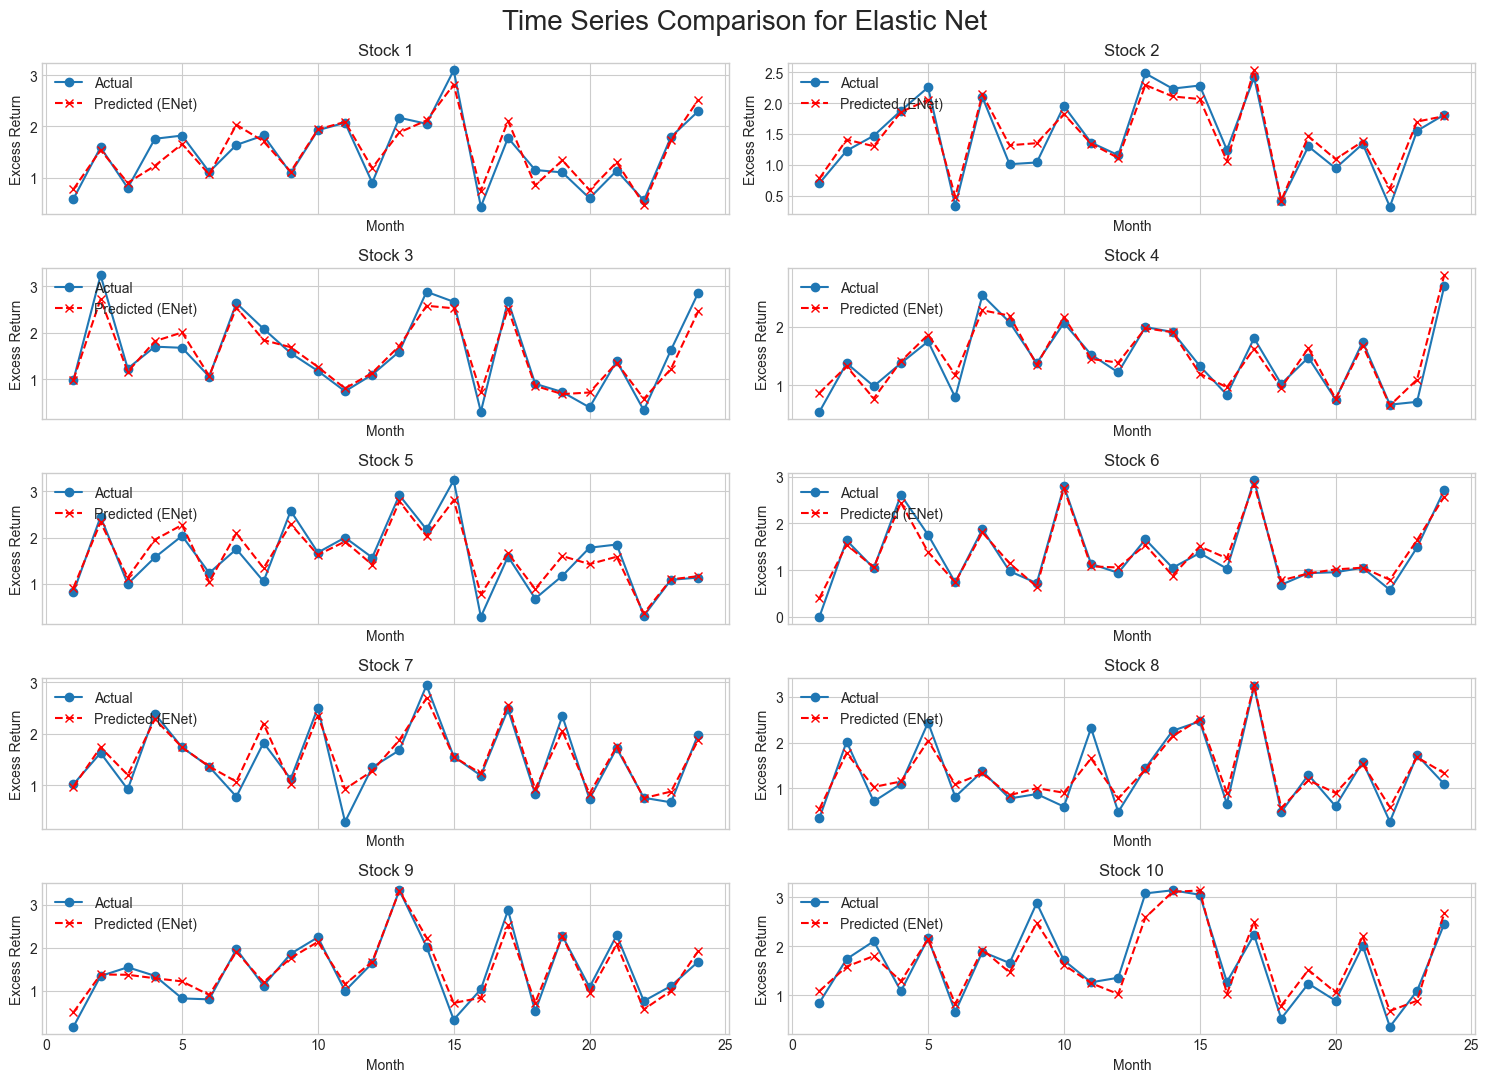

In [500]:
# compute Elastic Net predictions for all observations
y_pred_enet_all = enet.predict(X_all)

# plot actual vs. Elastic Net predicted per stock
fig, axes = plt.subplots(5, 2, sharex=True, figsize=(15, 11))
axes = axes.flatten()
fig.suptitle("Time Series Comparison for Elastic Net", fontsize=20)

for i, stock_id in enumerate(sorted(combined_data['Stock_ID'].unique())):
    df_s = combined_data[combined_data['Stock_ID'] == stock_id].sort_values('Month')
    idx  = df_s.index  # original indices for this stock
    
    axes[i].plot(
        df_s['Month'], df_s['Excess_Return'],
        marker='o', linestyle='-', label='Actual'
    )
    axes[i].plot(
        df_s['Month'], y_pred_enet_all[idx],
        marker='x', linestyle='--', color='red', label='Predicted (ENet)'
    )
    axes[i].set_title(f"Stock {stock_id}")
    axes[i].set_xlabel("Month")
    axes[i].set_ylabel("Excess Return")
    axes[i].legend(loc='upper left')

plt.tight_layout()
plt.show()

### Principal Component Regression (PCR)

Principal Component Regression (PCR) is a two-stage technique that combines **Principal Component Analysis (PCA)** for dimensionality reduction with **linear regression** on the resulting components. It addresses issues of multicollinearity by projecting the original features onto a lower-dimensional orthogonal basis before fitting the regression model.

The steps are:

1. **PCA**: Decompose the predictor matrix $X$ into orthogonal components (principal components), retaining only the first $k$ that explain the most variance.
2. **Regression**: Fit a linear model using the first $k$ principal components instead of the original predictors.

Formally, we solve:

$$
X = U \Sigma V^\top \quad \Rightarrow \quad X_{\text{reduced}} = X V_k \\
y = X_{\text{reduced}} \beta + \varepsilon
$$

PCR is especially useful when:
- The number of predictors is large or highly correlated
- The goal is to reduce overfitting by discarding noisy or redundant components

In this implementation, the optimal number of components $k$ is chosen via cross-validation to minimize validation mean squared error. The final model is then fit on the reduced training + validation set and used to predict on the test set.


In [501]:
# --- Principal Component Regression (PCR) ---

# 1) Tune number of components (k) using validation set
best_pcr = {"mse": np.inf, "k": None}

for k in range(1, min(X_train.shape[1], 20) + 1):
    # a) Fit PCA with k components on training data
    pca_tune = PCA(n_components=k).fit(X_train)
    
    # b) Transform both training and validation sets
    X_train_pca = pca_tune.transform(X_train)
    X_val_pca   = pca_tune.transform(X_val)
    
    # c) Fit linear regression on reduced training data
    lr_tune = LinearRegression().fit(X_train_pca, y_train)
    
    # d) Predict on validation set and compute MSE
    y_val_pred = lr_tune.predict(X_val_pca)
    mse_val    = mean_squared_error(y_val, y_val_pred)
    
    # e) Update best number of components if MSE improved
    if mse_val < best_pcr["mse"]:
        best_pcr.update({"mse": mse_val, "k": k})

# 2) Re-fit PCA on combined training + validation set with best k
pca_final = PCA(n_components=best_pcr["k"])
X_trval   = np.vstack([X_train, X_val])
X_trval_pca = pca_final.fit_transform(X_trval)

# 3) Fit final regression on reduced train+val data
lr_pcr = LinearRegression().fit(X_trval_pca, np.concatenate([y_train, y_val]))

# 4) Transform test set and make PCR predictions
X_test_pca   = pca_final.transform(X_test)
y_pred_pcr   = lr_pcr.predict(X_test_pca)

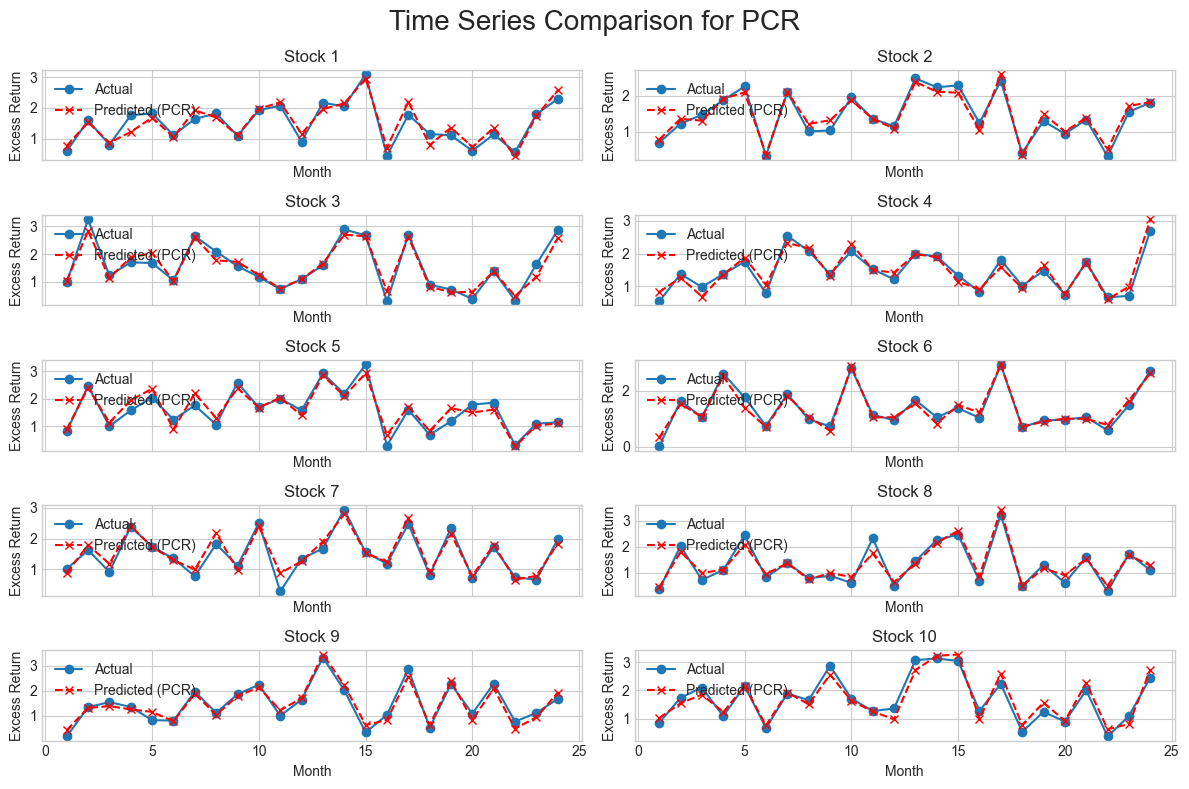

In [502]:
# --- PCR plotting with your fitted objects ---
X_all_pca     = pca_final.transform(X_all)       # use pca_final
y_pred_pcr_all = lr_pcr.predict(X_all_pca)       # use lr_pcr

fig, axes = plt.subplots(5, 2, sharex=True, figsize=(12, 8))
axes = axes.flatten()
fig.suptitle("Time Series Comparison for PCR", fontsize=20)

for i, stock_id in enumerate(sorted(combined_data['Stock_ID'].unique())):
    df_s = combined_data[combined_data['Stock_ID'] == stock_id].sort_values('Month')
    idx  = df_s.index

    axes[i].plot(df_s['Month'], df_s['Excess_Return'],
                 marker='o', linestyle='-', label='Actual')
    axes[i].plot(df_s['Month'], y_pred_pcr_all[idx],
                 marker='x', linestyle='--', color='red', label='Predicted (PCR)')
    axes[i].set_title(f"Stock {stock_id}")
    axes[i].set_xlabel("Month")
    axes[i].set_ylabel("Excess Return")
    axes[i].legend(loc='upper left')

plt.tight_layout()
plt.show()


### Partial Least Squares (PLS) Regression

Partial Least Squares (PLS) regression is a supervised dimensionality reduction technique that combines feature extraction with regression. Unlike Principal Component Regression (PCR), which ignores the response variable during dimensionality reduction, PLS identifies components that maximize the **covariance between predictors and the response**.

PLS constructs latent components by projecting both $X$ and $y$ onto a lower-dimensional space such that:

- The extracted components explain as much variation in $X$ as possible
- They are also highly predictive of $y$

Mathematically, PLS seeks components $T = XW$ such that:

$$
\text{Cov}(T, y) \text{ is maximized}
$$

PLS is particularly effective when:
- Predictors are highly collinear or numerous
- There is a need to reduce dimensionality while preserving predictive power

In this implementation, the number of PLS components is selected via validation to minimize the prediction error. The final model is trained on the full training and validation set, and used to generate predictions on the test data.


In [503]:
# --- Partial Least Squares Regression (PLS) ---

# 1) Tune number of PLS components using the validation set
best_pls = {"mse": np.inf, "n_components": None}

for n_comp in range(1, min(X_train.shape[1], 20) + 1):
    # a) Initialize and fit PLS with n_comp components
    pls_tune = PLSRegression(n_components=n_comp).fit(X_train, y_train)
    
    # b) Predict on validation set
    y_val_pred = pls_tune.predict(X_val)
    
    # c) Compute validation MSE
    mse_val = mean_squared_error(y_val, y_val_pred)
    
    # d) Update best configuration if current MSE is lower
    if mse_val < best_pls["mse"]:
        best_pls.update({"mse": mse_val, "n_components": n_comp})

# 2) Refit PLS on combined train+val data with the best number of components
pls_final = PLSRegression(n_components=best_pls["n_components"])
X_trval = np.vstack([X_train, X_val])
y_trval = np.concatenate([y_train, y_val])
pls_final.fit(X_trval, y_trval)

# 3) Generate test-set predictions and flatten to 1D array
y_pred_pls = pls_final.predict(X_test).flatten()

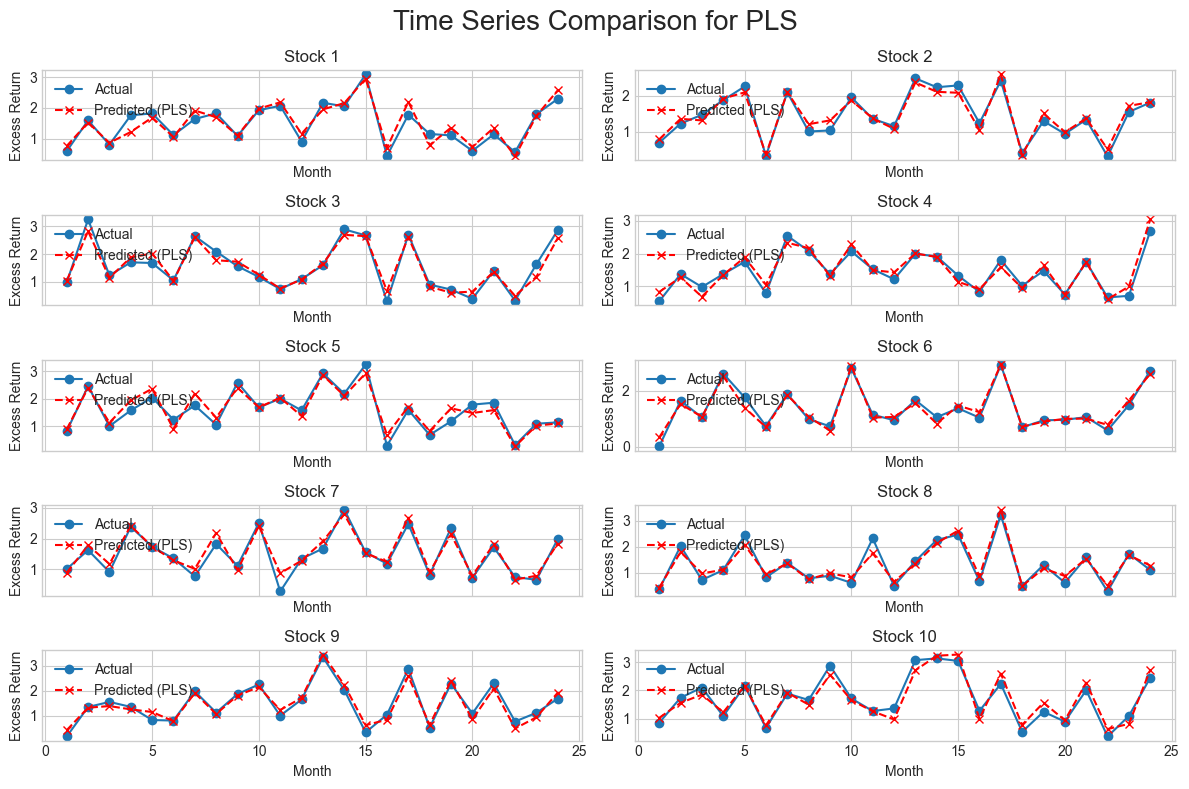

In [504]:
# compute PLS predictions for all observations
y_pred_pls_all = pls_final.predict(X_all).flatten()

# plot actual vs. PLS predicted per stock
fig, axes = plt.subplots(5, 2, sharex=True, figsize=(12, 8))
axes = axes.flatten()
fig.suptitle("Time Series Comparison for PLS", fontsize=20)

for i, stock_id in enumerate(sorted(combined_data['Stock_ID'].unique())):
    df_s = combined_data[combined_data['Stock_ID'] == stock_id].sort_values('Month')
    idx  = df_s.index

    axes[i].plot(
        df_s['Month'], df_s['Excess_Return'],
        marker='o', linestyle='-', label='Actual'
    )
    axes[i].plot(
        df_s['Month'], y_pred_pls_all[idx],
        marker='x', linestyle='--', color='red', label='Predicted (PLS)'
    )
    axes[i].set_title(f"Stock {stock_id}")
    axes[i].set_xlabel("Month")
    axes[i].set_ylabel("Excess Return")
    axes[i].legend(loc='upper left')

plt.tight_layout()
plt.show()

### Generalized Linear Model (GLM) with Spline Expansion and ElasticNet Regularization

This model applies a Generalized Linear Modeling (GLM) framework with **nonlinear feature transformation** and **regularization**. The input features are first expanded using **B-spline basis functions**, allowing the model to capture nonlinear effects. Then, an **ElasticNet regression** is applied to the transformed data to control model complexity and perform variable selection.

The steps are as follows:

1. **Spline Transformation**: Each original feature is expanded into a set of basis functions using degree-$d$ splines with $k$ uniformly placed knots. This transforms the design matrix into a richer, nonlinear feature space.

2. **ElasticNet Regularization**: On the spline-expanded data, an ElasticNet model is fit by minimizing:

$$
\min_\beta \left\{ \frac{1}{2n} \sum_{i=1}^{n} (y_i - x_i^\top \beta)^2 + \alpha \left[ \lambda \|\beta\|_1 + \frac{1 - \lambda}{2} \|\beta\|_2^2 \right] \right\}
$$

ElasticNet balances L1 (Lasso) and L2 (Ridge) penalties, which is particularly helpful when the number of transformed features is large and multicollinear.

This combination allows the GLM to model flexible, nonlinear relationships while still maintaining generalization through regularization. Hyperparameters (spline degree, number of knots, $\alpha$, and $\lambda$) are tuned to minimize validation error.


In [505]:
# --- Generalized Linear Model (GLM) with Spline Expansion + Elastic Net Regularization ---

# 1) Spline-transform the original features
spline_degree = 2
n_knots = 5
spline = SplineTransformer(
    degree=spline_degree,
    n_knots=n_knots,
    knots="uniform",
    include_bias=False
)
X_train_spline = spline.fit_transform(X_train)
X_val_spline   = spline.transform(X_val)
X_test_spline  = spline.transform(X_test)

# 2) Hyperparameter tuning on the validation set
best_glm = {"mse": np.inf, "alpha": None, "l1_ratio": None}
alpha_grid = np.logspace(-3, 1, 10)
l1_ratios  = [0.1, 0.5, 0.9]

for alpha in alpha_grid:
    for l1 in l1_ratios:
        # initialize ElasticNet with current hyperparameters
        glm_candidate = ElasticNet(
            alpha=alpha,
            l1_ratio=l1,
            max_iter=10000,
            random_state=42
        )
        # fit on spline-expanded training data
        glm_candidate.fit(X_train_spline, y_train)
        # predict on spline-expanded validation data
        y_val_pred = glm_candidate.predict(X_val_spline)
        val_mse    = mean_squared_error(y_val, y_val_pred)
        
        # update best hyperparameters if MSE improves
        if val_mse < best_glm["mse"]:
            best_glm.update({"mse": val_mse, "alpha": alpha, "l1_ratio": l1})

# 3) Refit the final model on combined train+val data
glm_final = ElasticNet(
    alpha=best_glm["alpha"],
    l1_ratio=best_glm["l1_ratio"],
    max_iter=10000,
    random_state=42
)
X_combined_spline = np.vstack([X_train_spline, X_val_spline])
y_combined        = np.concatenate([y_train, y_val])
glm_final.fit(X_combined_spline, y_combined)

# 4) Generate GLM predictions on the test set
y_pred_glm = glm_final.predict(X_test_spline)


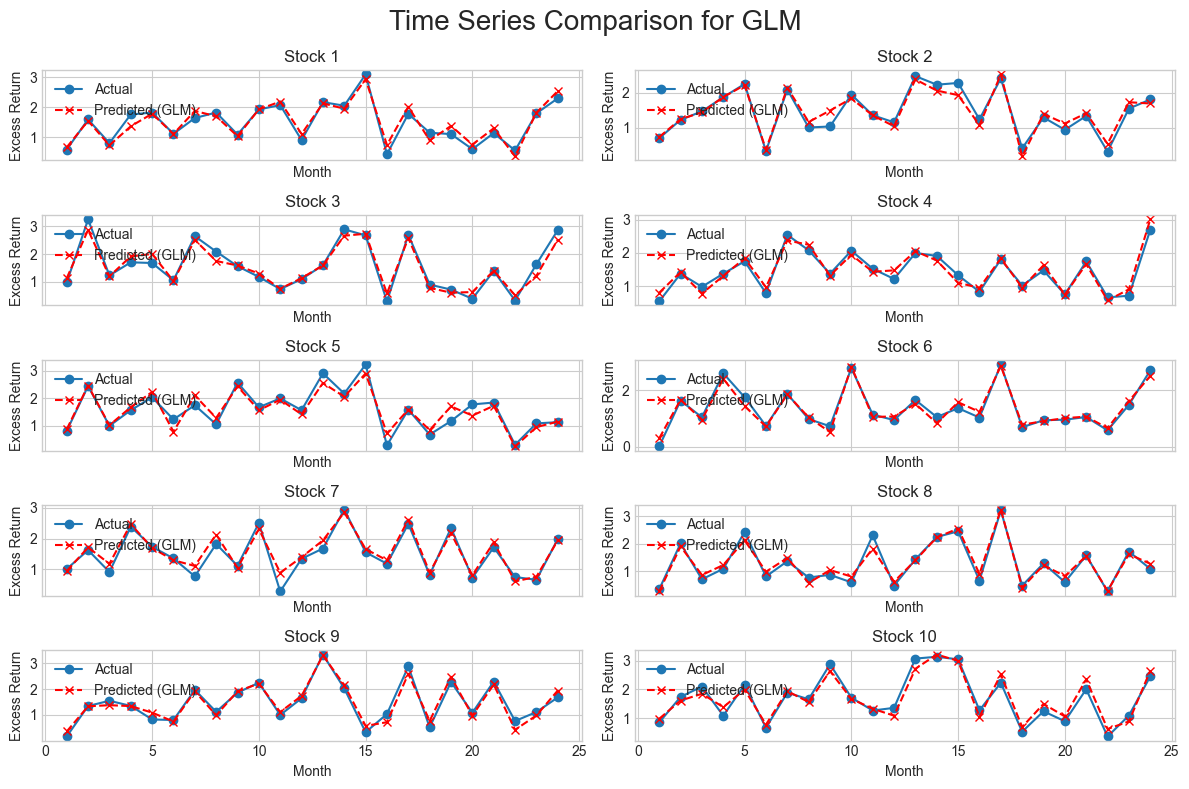

In [506]:
# compute GLM predictions for all observations using the final fitted model
X_all_spline  = spline.transform(X_all)
glm_pred_all  = glm_final.predict(X_all_spline)

# plot actual vs. GLM predicted per stock
fig, axes = plt.subplots(5, 2, sharex=True, figsize=(12, 8))
axes = axes.flatten()
fig.suptitle("Time Series Comparison for GLM", fontsize=20)

for i, stock_id in enumerate(sorted(combined_data['Stock_ID'].unique())):
    df_s = combined_data[combined_data['Stock_ID'] == stock_id].sort_values('Month')
    idx  = df_s.index

    axes[i].plot(
        df_s['Month'], df_s['Excess_Return'],
        marker='o', linestyle='-', label='Actual'
    )
    axes[i].plot(
        df_s['Month'], glm_pred_all[idx],
        marker='x', linestyle='--', color='red', label='Predicted (GLM)'
    )
    axes[i].set_title(f"Stock {stock_id}")
    axes[i].set_xlabel("Month")
    axes[i].set_ylabel("Excess Return")
    axes[i].legend(loc='upper left')

plt.tight_layout()
plt.show()


### Gradient Boosting Regressor (GBR)

Gradient Boosting is an ensemble learning technique that builds a sequence of weak learners—typically shallow decision trees—where each learner attempts to correct the errors of its predecessor. The model minimizes a differentiable loss function (e.g., squared error) using gradient descent in function space.

At each stage $m$, the model is updated as:

$$
F_m(x) = F_{m-1}(x) + \nu \cdot h_m(x)
$$

where:
- $F_{m-1}(x)$ is the current ensemble prediction,
- $h_m(x)$ is the new base learner fit to the negative gradient (residuals),
- $\nu$ is the learning rate controlling the contribution of each tree.

Key hyperparameters include:
- $n_{\text{estimators}}$: the number of boosting stages (trees),
- $learning\_rate$: step size shrinkage,
- $max\_depth$: depth of individual trees, controlling complexity.

In this implementation, a grid search is used to tune the model by minimizing validation RMSE. The best configuration is then refit on the combined training and validation set to produce final predictions on the test set.

Gradient Boosting excels at capturing complex nonlinear relationships and interactions, especially in structured/tabular data.


In [507]:
# --- Gradient Boosting Regressor (GBR) ---

# 1) Define hyperparameter grid
param_grid = {
    "n_estimators": [50, 100, 200],
    "learning_rate": [0.01, 0.1, 0.2],
    "max_depth": [3, 5, 7]
}

# 2) Grid search on validation set to find best params
best_gbr = {"rmse": np.inf, "params": None}

for n_trees in param_grid["n_estimators"]:
    for lr in param_grid["learning_rate"]:
        for depth in param_grid["max_depth"]:
            # initialize model with current combination
            candidate = GradientBoostingRegressor(
                n_estimators=n_trees,
                learning_rate=lr,
                max_depth=depth,
                random_state=42
            )
            # fit on training data
            candidate.fit(X_train, y_train)
            # predict and compute RMSE on validation set
            val_preds = candidate.predict(X_val)
            val_rmse  = np.sqrt(mean_squared_error(y_val, val_preds))
            # update best if improved
            if val_rmse < best_gbr["rmse"]:
                best_gbr["rmse"]   = val_rmse
                best_gbr["params"] = {
                    "n_estimators": n_trees,
                    "learning_rate": lr,
                    "max_depth": depth
                }


# 3) Retrain final model on combined train+validation set
X_trval = np.vstack([X_train, X_val])
y_trval = np.concatenate([y_train, y_val])

gbr_final = GradientBoostingRegressor(
    **best_gbr["params"],
    random_state=42
)
gbr_final.fit(X_trval, y_trval)

y_pred_gbr = gbr_final.predict(X_test)

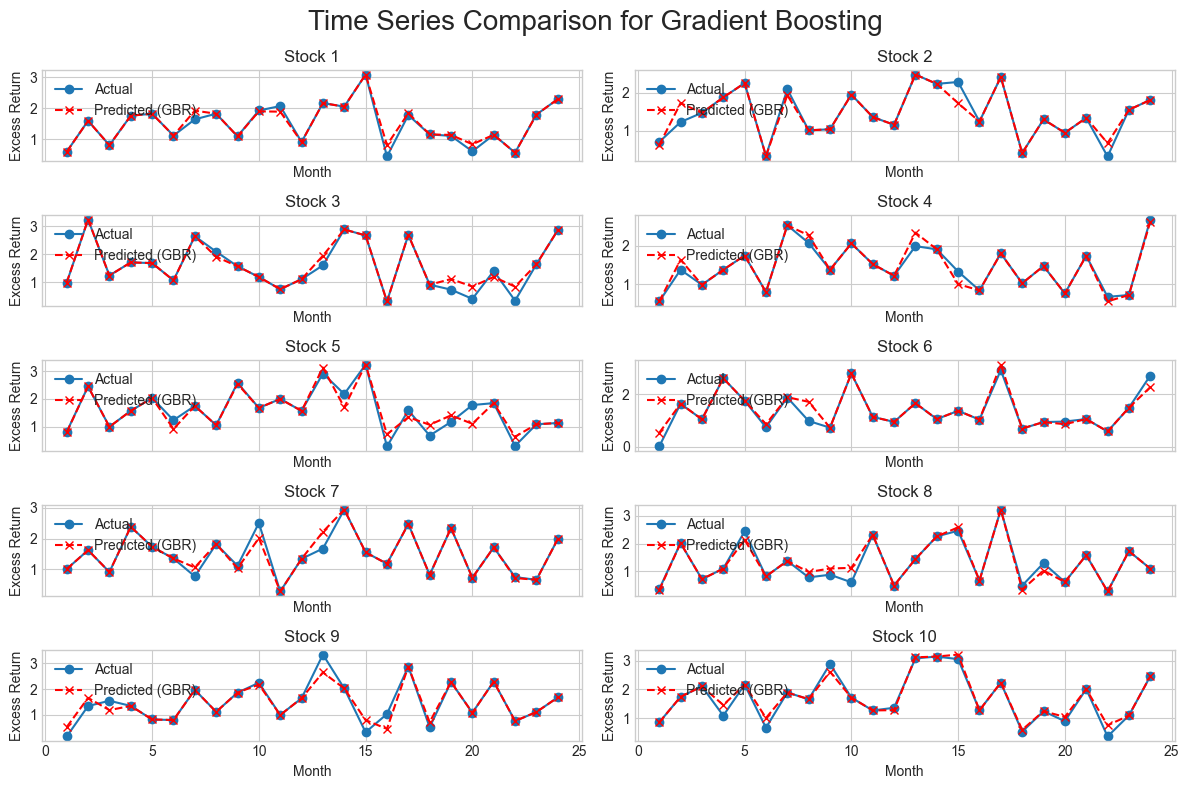

In [508]:
# compute GBR predictions for all observations
y_pred_gbr_all = gbr_final.predict(X_all)

# plot actual vs. GBR predicted per stock
fig, axes = plt.subplots(5, 2, sharex=True, figsize=(12, 8))
axes = axes.flatten()
fig.suptitle("Time Series Comparison for Gradient Boosting", fontsize=20)

for i, stock_id in enumerate(sorted(combined_data['Stock_ID'].unique())):
    df_s = combined_data[combined_data['Stock_ID'] == stock_id].sort_values('Month')
    idx  = df_s.index

    # actual returns
    axes[i].plot(
        df_s['Month'], df_s['Excess_Return'],
        marker='o', linestyle='-', label='Actual'
    )
    # predicted returns
    axes[i].plot(
        df_s['Month'], y_pred_gbr_all[idx],
        marker='x', linestyle='--', color='red', label='Predicted (GBR)'
    )
    axes[i].set_title(f"Stock {stock_id}")
    axes[i].set_xlabel("Month")
    axes[i].set_ylabel("Excess Return")
    axes[i].legend(loc='upper left')

plt.tight_layout()
plt.show()


### Random Forest Regressor (RF)

Random Forest is an ensemble learning method based on **bagging** (bootstrap aggregating) that constructs a collection of decision trees and averages their predictions to reduce variance and improve generalization. Each tree is trained on a different bootstrap sample of the data and selects a random subset of features at each split, encouraging model diversity.

The prediction for input $x$ is given by:

$$
\hat{y}(x) = \frac{1}{T} \sum_{t=1}^{T} h_t(x)
$$

where $h_t(x)$ is the prediction from tree $t$, and $T$ is the total number of trees.

Key hyperparameters include:
- $n_{\text{estimators}}$: number of trees in the forest,
- $max\_depth$: maximum depth of each tree,
- $min\_samples\_split$: minimum number of samples required to split an internal node.

Random Forests handle high-dimensional data well, are robust to overfitting, and can capture complex nonlinear relationships without much tuning. They also offer feature importance metrics out of the box.

In this implementation, hyperparameters are selected via grid search on a validation set using RMSE as the performance criterion. The final model is trained on the full training and validation data before generating predictions on the test set.


In [509]:
# --- Random Forest Regressor (RF) ---

# 1) Define hyperparameter grid
rf_param_grid = {
    "n_estimators":    [50, 100, 200],
    "max_depth":       [3, 5, 7],
    "min_samples_split": [2, 5, 10]
}

best_rf = {"rmse": np.inf, "params": None}

# 2) Grid search on validation set
for n_trees in rf_param_grid["n_estimators"]:
    for depth in rf_param_grid["max_depth"]:
        for min_split in rf_param_grid["min_samples_split"]:
            # initialize candidate model
            rf_candidate = RandomForestRegressor(
                n_estimators=n_trees,
                max_depth=depth,
                min_samples_split=min_split,
                random_state=42,
                n_jobs=-1
            )
            rf_candidate.fit(X_train, y_train)
            
            # predict & evaluate on validation set
            y_val_pred = rf_candidate.predict(X_val)
            val_rmse   = np.sqrt(mean_squared_error(y_val, y_val_pred))
            
            # keep track of best configuration
            if val_rmse < best_rf["rmse"]:
                best_rf["rmse"]   = val_rmse
                best_rf["params"] = {
                    "n_estimators": n_trees,
                    "max_depth": depth,
                    "min_samples_split": min_split
                }


# 3) Retrain final model on combined train+validation data
X_trval = np.vstack([X_train, X_val])
y_trval = np.concatenate([y_train, y_val])

rf_final = RandomForestRegressor(
    **best_rf["params"],
    random_state=42,
    n_jobs=-1
)
rf_final.fit(X_trval, y_trval)

# 4) Generate predictions on the test set
y_pred_rf = rf_final.predict(X_test)


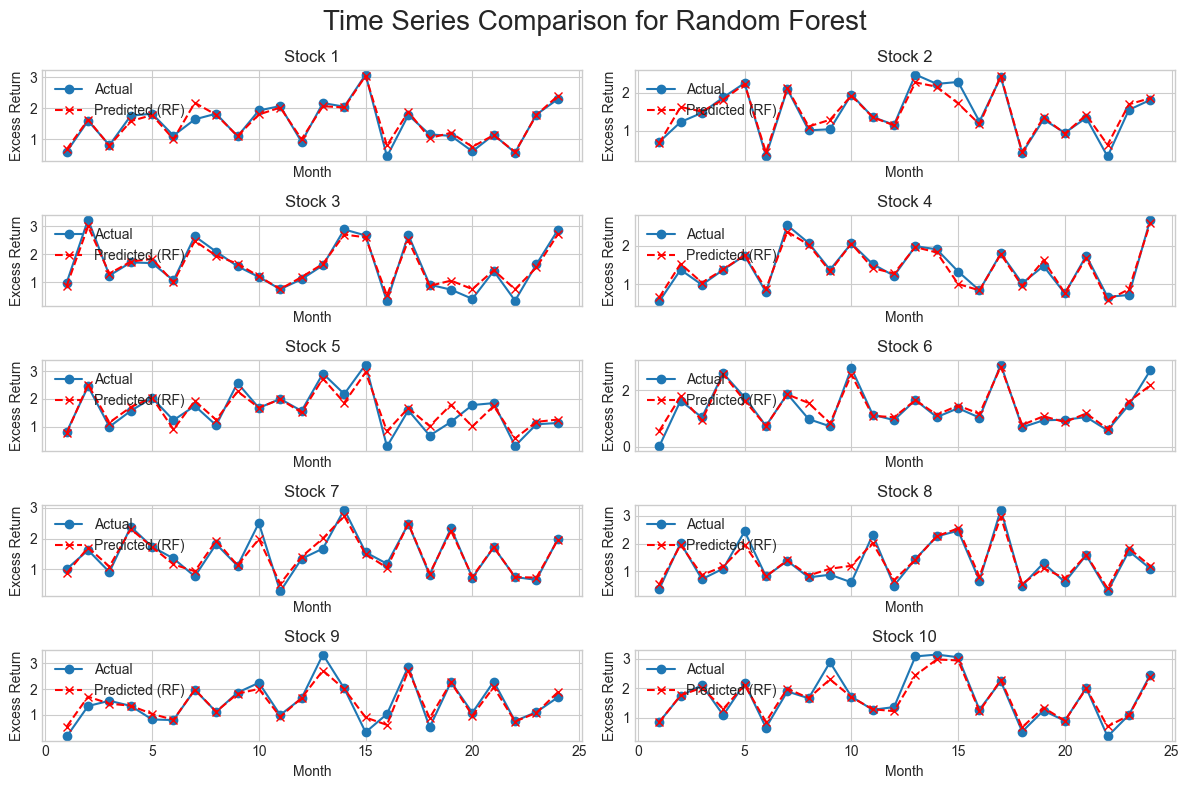

In [510]:
# compute RF predictions for all observations
y_pred_rf_all = rf_final.predict(X_all)

# plot actual vs. RF predicted per stock
fig, axes = plt.subplots(5, 2, sharex=True, figsize=(12, 8))
axes = axes.flatten()
fig.suptitle("Time Series Comparison for Random Forest", fontsize=20)

for i, stock_id in enumerate(sorted(combined_data['Stock_ID'].unique())):
    df_s = combined_data[combined_data['Stock_ID'] == stock_id].sort_values('Month')
    idx  = df_s.index

    axes[i].plot(
        df_s['Month'], df_s['Excess_Return'],
        marker='o', linestyle='-', label='Actual'
    )
    axes[i].plot(
        df_s['Month'], y_pred_rf_all[idx],
        marker='x', linestyle='--', color='red', label='Predicted (RF)'
    )
    axes[i].set_title(f"Stock {stock_id}")
    axes[i].set_xlabel("Month")
    axes[i].set_ylabel("Excess Return")
    axes[i].legend(loc='upper left')

plt.tight_layout()
plt.show()


### Neural Network Regressor

Neural Networks are flexible, non-linear function approximators that can model complex patterns in data through layered transformations. In this implementation, we use a **fully connected feedforward architecture** with three hidden layers and ReLU activations.

The model has the general form:

$$
\hat{y} = f(x; \theta) = W_3 \cdot \text{ReLU}(W_2 \cdot \text{ReLU}(W_1 \cdot x + b_1) + b_2) + b_3
$$

where $W_i$ and $b_i$ denote the weights and biases in each layer, and $\text{ReLU}(x) = \max(0, x)$ introduces non-linearity.

#### Key steps in this implementation:

1. **Standardization**: All features are standardized (zero mean, unit variance) for stable training.
2. **Architecture Search**: We perform a grid search over different hyperparameters including learning rate and the number of hidden units in three layers.
3. **Training**: The model is trained with mean squared error loss using the Adam optimizer. Early stopping is applied to prevent overfitting.
4. **Selection**: The best model is chosen based on validation loss and then used for final prediction on the test set.

Neural Networks are especially powerful in capturing **nonlinear interactions** and **high-dimensional patterns**, but require careful tuning and regularization due to their capacity and sensitivity to overfitting.


In [511]:
# --- Neural Network ---
from sklearn.preprocessing import StandardScaler
from tensorflow import keras
from itertools import product # Improve readability in nested loop structure

# 1) Scale features
scaler = StandardScaler().fit(X_train)
X_tr_nn = scaler.transform(X_train)
X_val_nn = scaler.transform(X_val)
X_te_nn  = scaler.transform(X_test)

# 2) Model factory
def create_model(learning_rate=0.01, layer1_units=32, layer2_units=16, layer3_units=8):
    model = keras.Sequential([
        keras.Input(shape=(X_tr_nn.shape[1],)),
        keras.layers.Dense(layer1_units, activation='relu'),
        keras.layers.Dense(layer2_units, activation='relu'),
        keras.layers.Dense(layer3_units, activation='relu'),
        keras.layers.Dense(1)
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='mse',
        metrics=['mae']
    )
    return model

# 3) Hyperparameter grid
learning_rates = [0.001, 0.01, 0.1]
layer1_units   = [32, 64]
layer2_units   = [16, 32]
layer3_units   = [8, 16]

early_stop = keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)

best_nn = {"val_loss": float('inf'), "params": None, "model": None}

# 4) Grid search over all combinations
for lr, n1, n2, n3 in product(learning_rates, layer1_units, layer2_units, layer3_units):
    model = create_model(learning_rate=lr,
                         layer1_units=n1,
                         layer2_units=n2,
                         layer3_units=n3)
    history = model.fit(
        X_tr_nn, y_train,
        validation_data=(X_val_nn, y_val),
        epochs=50,
        batch_size=32,
        callbacks=[early_stop],
        verbose=0
    )
    val_loss = min(history.history['val_loss'])
    if val_loss < best_nn['val_loss']:
        best_nn.update({
            "val_loss": val_loss,
            "params": {"lr": lr, "layer1": n1, "layer2": n2, "layer3": n3},
            "model": model
        })

# 5) Final model and test predictions
nn_final  = best_nn["model"]
y_pred_nn = nn_final.predict(X_te_nn).flatten()


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


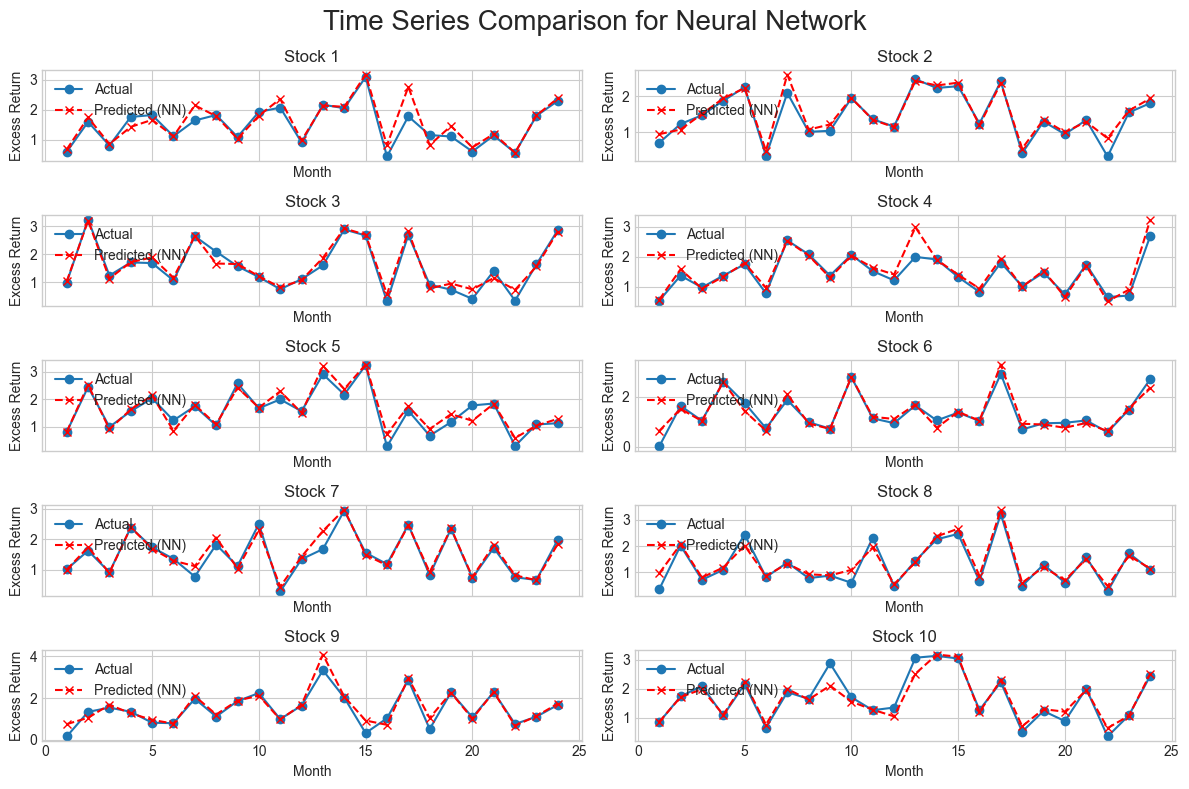

In [512]:
# compute NN predictions for all observations
X_all_nn       = scaler.transform(X_all)
y_pred_nn_all  = nn_final.predict(X_all_nn).flatten()

# plot actual vs. NN predicted per stock
fig, axes = plt.subplots(5, 2, sharex=True, figsize=(12, 8))
axes = axes.flatten()
fig.suptitle("Time Series Comparison for Neural Network", fontsize=20)

for i, stock_id in enumerate(sorted(combined_data['Stock_ID'].unique())):
    df_s = combined_data[combined_data['Stock_ID'] == stock_id].sort_values('Month')
    idx  = df_s.index

    axes[i].plot(
        df_s['Month'], df_s['Excess_Return'],
        marker='o', linestyle='-', label='Actual'
    )
    axes[i].plot(
        df_s['Month'], y_pred_nn_all[idx],
        marker='x', linestyle='--', color='red', label='Predicted (NN)'
    )
    axes[i].set_title(f"Stock {stock_id}")
    axes[i].set_xlabel("Month")
    axes[i].set_ylabel("Excess Return")
    axes[i].legend(loc='upper left')

plt.tight_layout()
plt.show()


---
---
### Out-of-Sample R²

The coefficient of determination ($R^2$) measures the proportion of variance in the target variable that is explained by a model. It is defined as:

$$
R^2 = 1 - \frac{\text{SSE}}{\text{TSS}} = 1 - \frac{\sum (y_i - \hat{y}_i)^2}{\sum y_i^2}
$$

In this out-of-sample setting, $y_i$ are the true test values and $\hat{y}_i$ are the model predictions. A higher $R^2$ indicates better predictive performance. An $R^2 < 0$ implies the model performs worse than a naive model that predicts zero for all observations.

In the context of stock return prediction, out-of-sample $R^2$ is crucial because financial returns are notoriously noisy and difficult to forecast. A positive $R^2$ indicates that the model captures meaningful signal beyond random variation—an essential requirement for building reliable trading strategies or asset allocation models.


Out-of-Sample R² Scores:
OLS: 0.985968901
WLS: 0.984380944
Huber: 0.983933173
ENet: 0.981037843
PCR: 0.984502971
PLS: 0.984465391
GLM: 0.982453613
NN: 0.945099954
GBR: 0.958761776
RF: 0.958657555


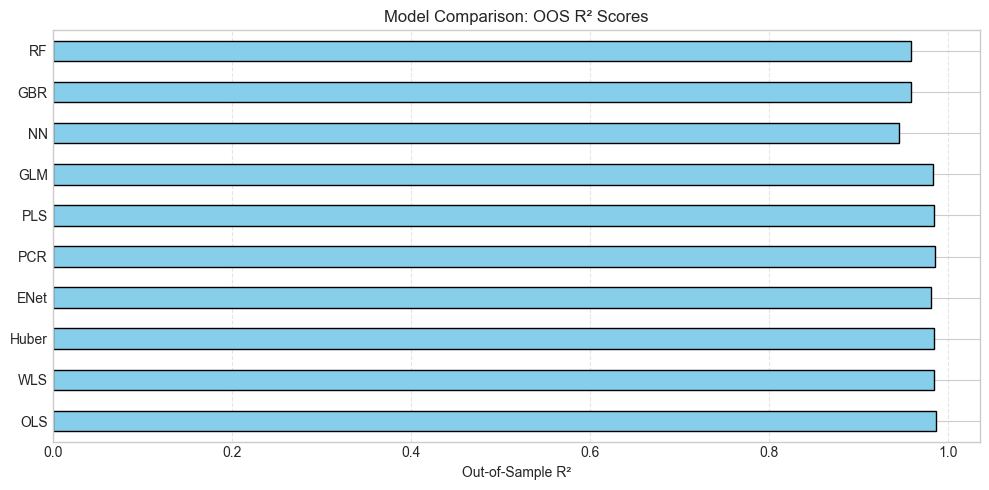

In [513]:


# ------------------------------------------
# Out-of-Sample R² Evaluation
# ------------------------------------------

def oos_r2(y_true, y_pred):
    """
    Computes out-of-sample R² = 1 - SSE / TSS
    """
    sse = np.sum((y_true - y_pred) ** 2)
    tss = np.sum(y_true ** 2)
    return 1 - sse / tss

# Desired model order
model_order = ['OLS', 'WLS', 'Huber', 'ENet', 'PCR', 'PLS', 'GLM', 'NN', 'GBR', 'RF']

# Dictionary of model predictions
models_preds = {
    'OLS': y_pred_ols,
    'WLS': y_pred_wls,
    'Huber': y_pred_huber,
    'ENet': y_pred_enet,
    'PCR': y_pred_pcr,
    'PLS': y_pred_pls,
    'GLM': y_pred_glm,
    'NN': y_pred_nn,
    'GBR': y_pred_gbr,
    'RF': y_pred_rf
}

# Compute and print R²
r2_scores = {}
print("Out-of-Sample R² Scores:")
for name in model_order:
    r2 = oos_r2(y_test, models_preds[name])
    r2_scores[name] = r2
    print(f"{name}: {r2:.9f}")

# Convert to DataFrame
r2_series = pd.Series(r2_scores)[model_order]

# Plot: Horizontal bar chart
plt.figure(figsize=(10, 5))
r2_series.plot(kind='barh', color='skyblue', edgecolor='black')
plt.xlabel("Out-of-Sample R²")
plt.title("Model Comparison: OOS R² Scores")
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### Interpretation of Out-of-Sample R² Scores on Synthetic Data

All models achieve high out-of-sample $R^2$ values, ranging from 0.96 to 0.99. This strong performance is expected given the structure of the synthetic dataset, which was generated using a known linear process with moderate dimensionality and low noise:

$$
r_{i,t+1} = z_{it}^\top \theta + \varepsilon, \quad \varepsilon \sim \mathcal{N}(0, 0.2^2)
$$

The Ordinary Least Squares (OLS) model performs best ($R^2 = 0.986$), as it directly corresponds to the data-generating mechanism. Regularized linear models such as WLS, Huber, and ElasticNet show slightly lower $R^2$ due to the introduction of bias, which is unnecessary in this idealized setting.

Dimensionality reduction techniques like Principal Component Regression (PCR) and Partial Least Squares (PLS) achieve nearly identical results to OLS, since the feature space is already well-behaved and relatively small (15 predictors).

In contrast, nonlinear models—including Generalized Linear Models with spline expansion, Neural Networks, Gradient Boosting, and Random Forests—underperform. These models are designed to capture complex nonlinear interactions, but in the absence of such structure, their flexibility leads to overfitting and unnecessary variance.

Overall, the results demonstrate that when the true relationship is linear and the signal-to-noise ratio is high, simple linear models outperform more complex alternatives. This reinforces the principle of aligning model complexity with the underlying structure of the data.


### Actual vs. Predicted Scatterplots

Scatterplots of predicted versus actual values provide a visual diagnostic for model performance. In an ideal scenario, all points should lie along the 45-degree line ($y = x$), indicating perfect predictions.

Deviations from this diagonal highlight systematic errors such as underprediction, overprediction, or heteroskedasticity. Well-aligned points suggest that the model captures the signal effectively, while large or structured deviations may indicate model misspecification or overfitting.

Such plots are particularly useful for comparing models side-by-side and identifying patterns that may not be visible through scalar metrics like $R^2$ or RMSE alone.


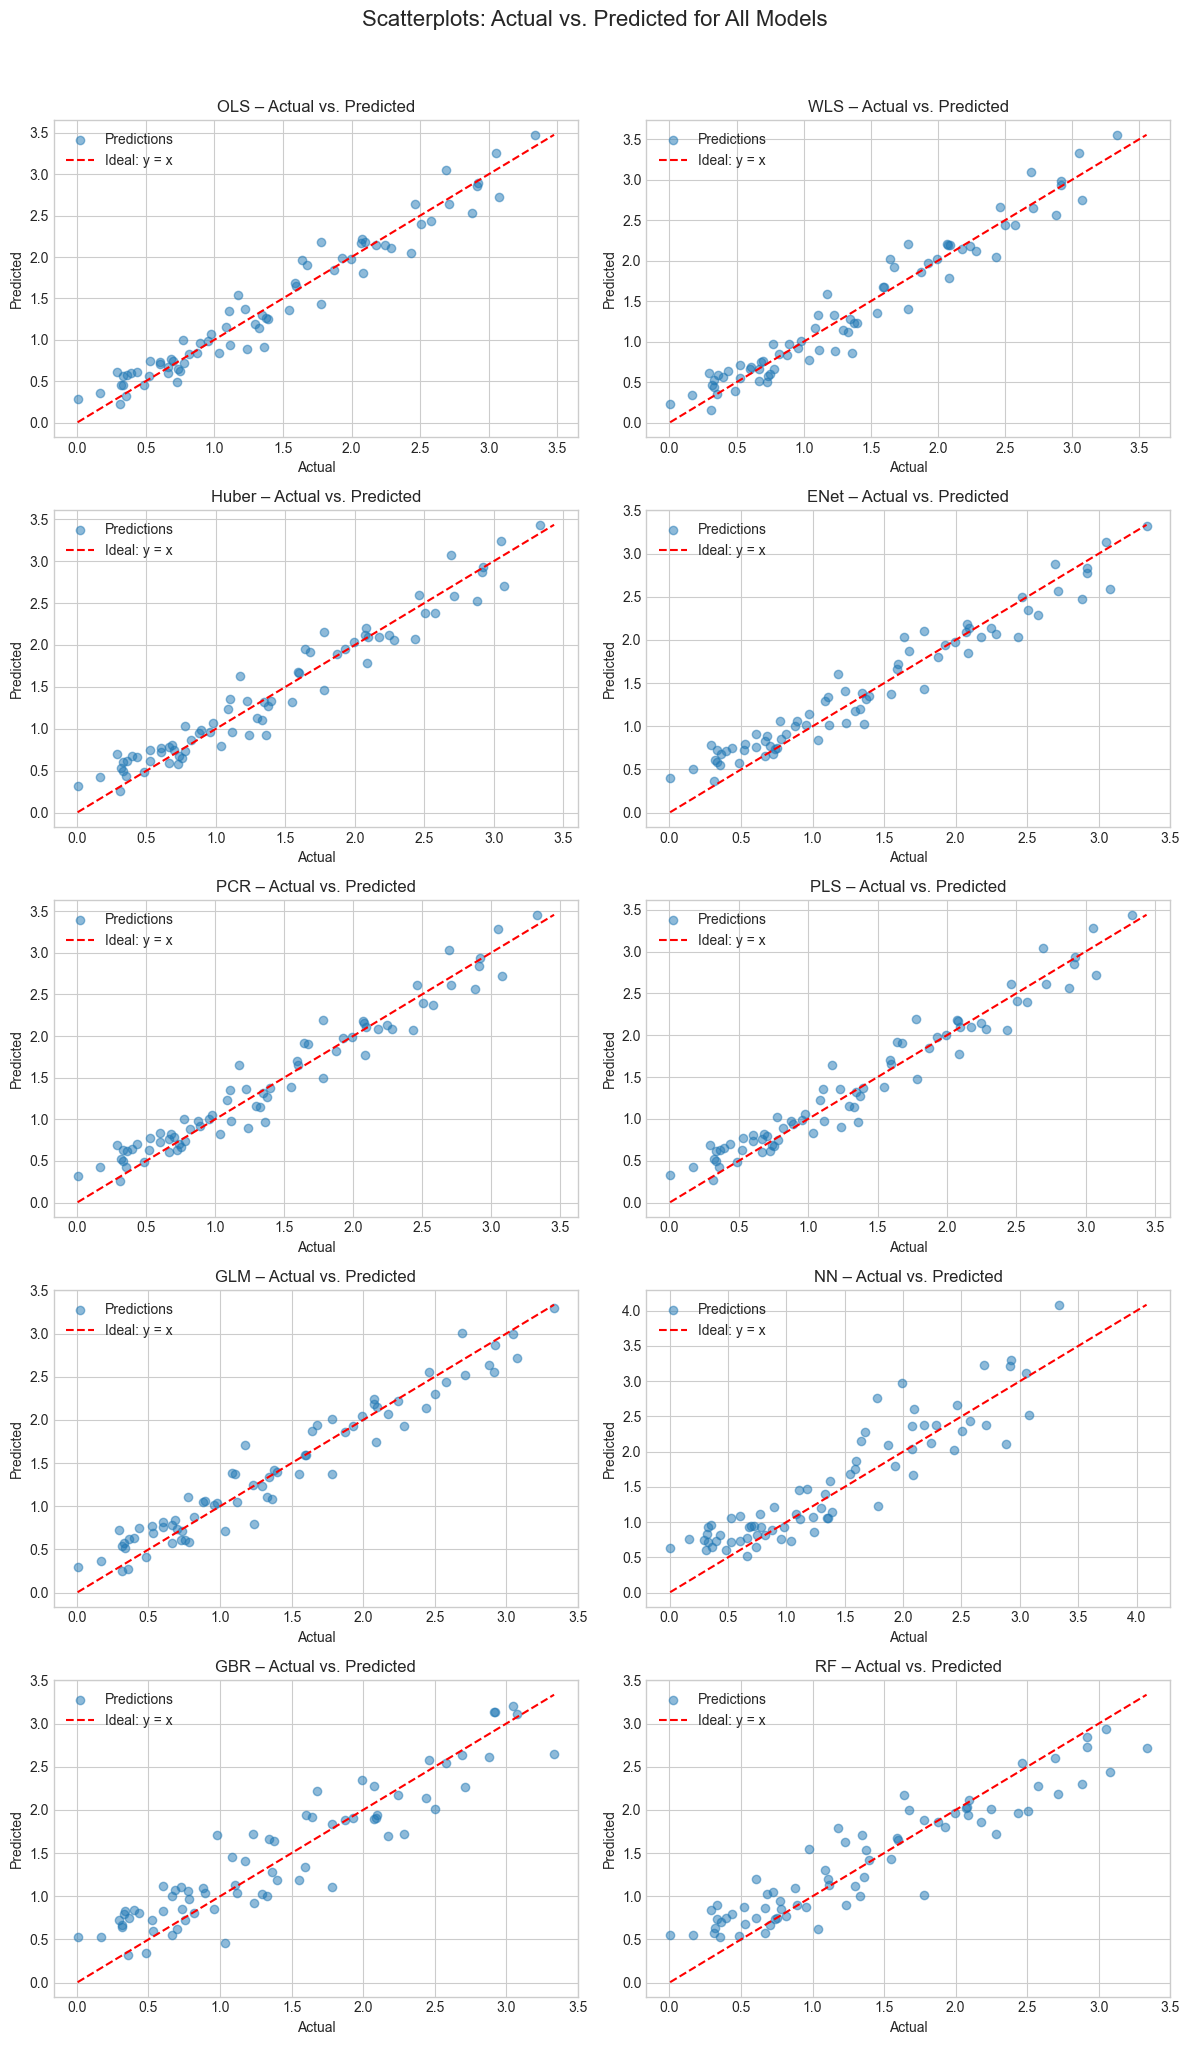

In [514]:
models = list(models_preds.keys())
n_models = len(models)
n_cols = 2
n_rows = int(np.ceil(n_models / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, n_rows * 4))
axes = axes.flatten()

for i, model in enumerate(models):
    ax = axes[i]
    y_pred = models_preds[model]
    ax.scatter(y_test, y_pred, alpha=0.5, label="Predictions")
    
    # Diagonale Linie (y = x)
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', label="Ideal: y = x")
    
    ax.set_title(f"{model} – Actual vs. Predicted")
    ax.set_xlabel("Actual")
    ax.set_ylabel("Predicted")
    ax.grid(True)
    ax.legend()

# Entferne überzählige Subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Scatterplots: Actual vs. Predicted for All Models", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

---
---
### Diebold–Mariano Test for Predictive Accuracy

The Diebold–Mariano (DM) test is a statistical method used to compare the predictive accuracy of two forecasting models. It evaluates whether the difference in forecast errors between two models is statistically significant, under the null hypothesis that both models have equal predictive performance.

Let $e^{(1)}_t$ and $e^{(2)}_t$ denote the forecast errors from two competing models. The DM test is based on the loss differential:

$$
d_t = L(e^{(1)}_t) - L(e^{(2)}_t)
$$

where $L(\cdot)$ is a loss function (typically squared error). The test statistic is computed as:

$$
DM = \frac{\bar{d}}{\hat{\sigma}_{\bar{d}}}
$$

where $\bar{d}$ is the sample mean of the loss differential, and $\hat{\sigma}_{\bar{d}}$ is its standard error, estimated using a Newey–West heteroskedasticity and autocorrelation consistent (HAC) estimator.

#### Code Summary

The code computes a full pairwise matrix of Diebold–Mariano statistics for all combinations of models using squared forecast errors on the test set. A heatmap shows the upper triangle of this matrix, where:

- Positive values indicate that the row model has **worse accuracy** than the column model.
- Negative values indicate **superior accuracy**.

To summarize each model’s relative performance, the code computes the **mean DM-statistic** of each model compared to all others. A barplot visualizes which models consistently perform better or worse relative to the rest.

This analysis allows not only model ranking, but also statistical comparison of forecasting performance beyond standard $R^2$ metrics.


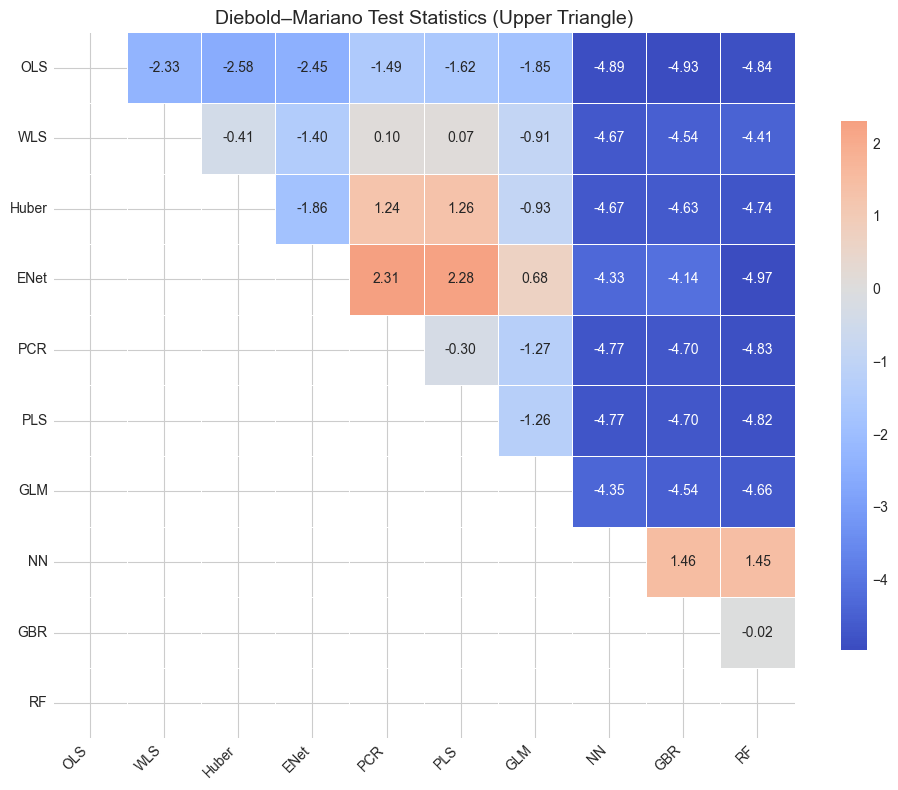

C:\Users\leven\AppData\Local\Temp\ipykernel_31624\3013958597.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


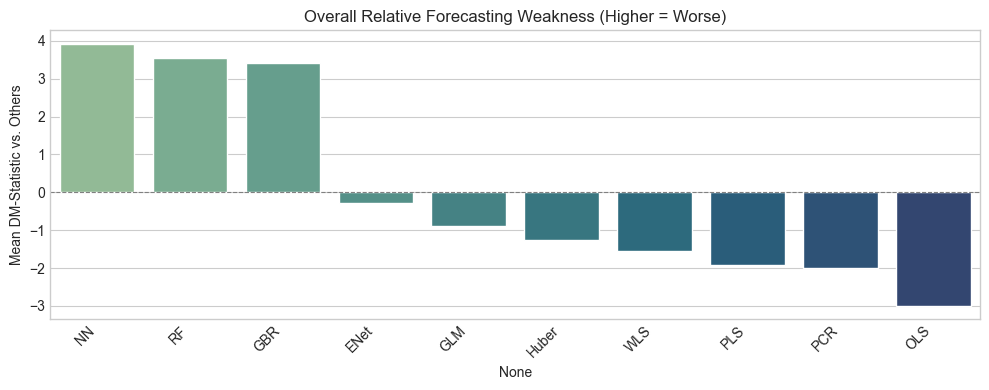

In [515]:
import itertools

# -----------------------------
# Step 1: Compute Squared Errors
# -----------------------------
squared_errors = {
    model: (y_test - models_preds[model]) ** 2
    for model in model_order
}

# -----------------------------
# Step 2: Newey–West SE Function
# -----------------------------
def newey_west_se(data, lag=1):
    n = len(data)
    mu = np.mean(data)
    gamma = [np.sum((data[:n - i] - mu) * (data[i:] - mu)) / n for i in range(lag + 1)]
    nw_var = gamma[0] + 2 * sum((1 - i / (lag + 1)) * gamma[i] for i in range(1, lag + 1))
    return np.sqrt(nw_var / n)

# -----------------------------
# Step 3: DM Test Matrix
# -----------------------------
dm_matrix = pd.DataFrame(index=model_order, columns=model_order, dtype=float)

for i, j in itertools.product(model_order, repeat=2):
    if i == j:
        dm_matrix.loc[i, j] = np.nan
    else:
        d = squared_errors[i] - squared_errors[j]
        dm_matrix.loc[i, j] = d.mean() / newey_west_se(d, lag=1)

# -----------------------------
# Step 4: Triangle Mask
# -----------------------------
upper_triangle_mask = np.tril(np.ones(dm_matrix.shape, dtype=bool), k=-1)

# -----------------------------
# Step 5: DM Heatmap (Upper Triangle)
# -----------------------------
plt.figure(figsize=(10, 8))
sns.heatmap(
    dm_matrix.astype(float),
    mask=upper_triangle_mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    cbar_kws={"shrink": 0.75}
)
plt.title("Diebold–Mariano Test Statistics (Upper Triangle)", fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# -----------------------------
# Step 6: Summary: Overall Model Strength (Mean vs. Others)
# -----------------------------
dm_summary = dm_matrix.copy()

# take row-wise mean ignoring NaN
dm_scores = dm_summary.mean(axis=1, skipna=True)

# sort descending (models with higher average relative loss)
dm_scores = dm_scores.sort_values(ascending=False)

# -----------------------------
# Step 7: Overall DM Score Plot
# -----------------------------
plt.figure(figsize=(10, 4))
sns.barplot(
    x=dm_scores.index,
    y=dm_scores.values,
    palette="crest"
)
plt.ylabel("Mean DM-Statistic vs. Others")
plt.title("Overall Relative Forecasting Weakness (Higher = Worse)")
plt.axhline(0, color="gray", linestyle="--", linewidth=0.8)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()



### Interpretation of Diebold–Mariano Test Results

The top heatmap visualizes pairwise Diebold–Mariano (DM) test statistics between all forecasting models. Each cell shows the DM-statistic comparing the row model to the column model based on squared forecast errors. Positive values indicate that the row model performs **worse** than the column model, while negative values suggest **better performance**.

Most values are negative for classical linear models (e.g., OLS, PCR, PLS), meaning they generally outperform more complex alternatives in this setting. In contrast, models like Random Forest (RF), Gradient Boosting (GBR), and Neural Networks (NN) exhibit positive DM statistics in many comparisons, implying relatively weaker accuracy.

The second plot summarizes these comparisons by displaying the **mean DM-statistic** of each model relative to all others. Models with higher average DM values (RF, GBR, NN) are consistently outperformed by others, while those with lower values (OLS, PCR, PLS) are more reliable in this experiment.

These findings reinforce that, for data generated from a simple linear process, **simpler models consistently outperform more flexible, nonlinear methods**. The DM test provides a statistically grounded way to confirm that these differences in accuracy are not due to chance.


In [516]:


# --------------------------------------
# 1) feature importance
# --------------------------------------

# Liste der Feature-Namen (wie in deinem Code)
features = [col for col in combined_data.columns if col.startswith('z_')]

# 1a) Prädiktionsfunktionen pro Modell (wie bei dir)
predict_fn = {
    'OLS':  lambda X: ols_model.predict(X),
    'WLS':  lambda X: wls.predict(X),
    'Huber':lambda X: huber_model.predict(X),
    'ENet': lambda X: enet.predict(X),
    'PCR':  lambda X: lr_pcr.predict(pca_final.transform(X)),
    'PLS':  lambda X: pls_final.predict(X).flatten(),
    'GLM':  lambda X: glm_final.predict(spline.transform(X)),
    'GBR':  lambda X: gbr_final.predict(X),
    'RF':   lambda X: rf_final.predict(X),
    'NN':   lambda X: nn_final.predict(scaler.transform(X)).flatten()
}


---
---
### Variable Importance via Drop-in R²

The code computes feature importance by measuring the drop in out-of-sample $R^2$ when each feature is individually "zeroed out" in the test set. For a given model, this method quantifies how much predictive power is lost when a specific feature is removed:

$$
\text{Importance}_j = R^2_{\text{full}} - R^2_{\text{without feature } j}
$$

This results in a feature-by-model importance matrix that highlights which predictors contribute most to each model’s performance.

In the context of stock return prediction, such variable importance analysis is crucial. It helps identify which combinations of firm characteristics and macroeconomic factors drive returns, offering insight into potential sources of risk premia and guiding the design of interpretable forecasting models.


In [517]:
# --------------------------------------
# 2) Variable Importance berechnen
# --------------------------------------
var_imp = {}
for name, fn in predict_fn.items():
    # Baseline-R²
    y_full  = fn(X_test)
    r2_full = r2_score(y_test, y_full)
    importances = []

    # Drop-in-R² je Feature
    for j in range(X_test.shape[1]):
        X_mod = X_test.copy()
        X_mod[:, j] = 0  # Feature j auf 0 setzen
        y_mod = fn(X_mod)
        r2_mod = r2_score(y_test, y_mod)
        importance = r2_full - r2_mod
        importances.append(importance)
    var_imp[name] = importances

# --------------------------------------
# 3) DataFrame (Feature × Modell)
# --------------------------------------
var_imp_df = pd.DataFrame(var_imp, index=features)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


### Interpretation of R² Variable Importance Heatmap

The heatmap visualizes the **drop in out-of-sample $R^2$** when each feature is removed (zeroed out) from the test data. Each cell quantifies how much predictive power a specific model loses without access to a given feature. Darker or brighter colors indicate stronger dependence on that feature.

This method provides a model-specific ranking of variable importance. For example, in the current plot, feature $z_6$ has the largest impact on predictive performance for Gradient Boosting and Random Forest, suggesting these models rely heavily on this input.

However, in this synthetic setting, all features were generated from random combinations of stock characteristics and macroeconomic factors, meaning the observed importances are **not economically meaningful**. The structure is an artifact of the simulation.

In real-world applications, where each $z$ corresponds to interpretable financial variables (e.g., size, value, momentum, interest rates), such an importance heatmap can offer valuable insights into the drivers of return predictability and model behavior.


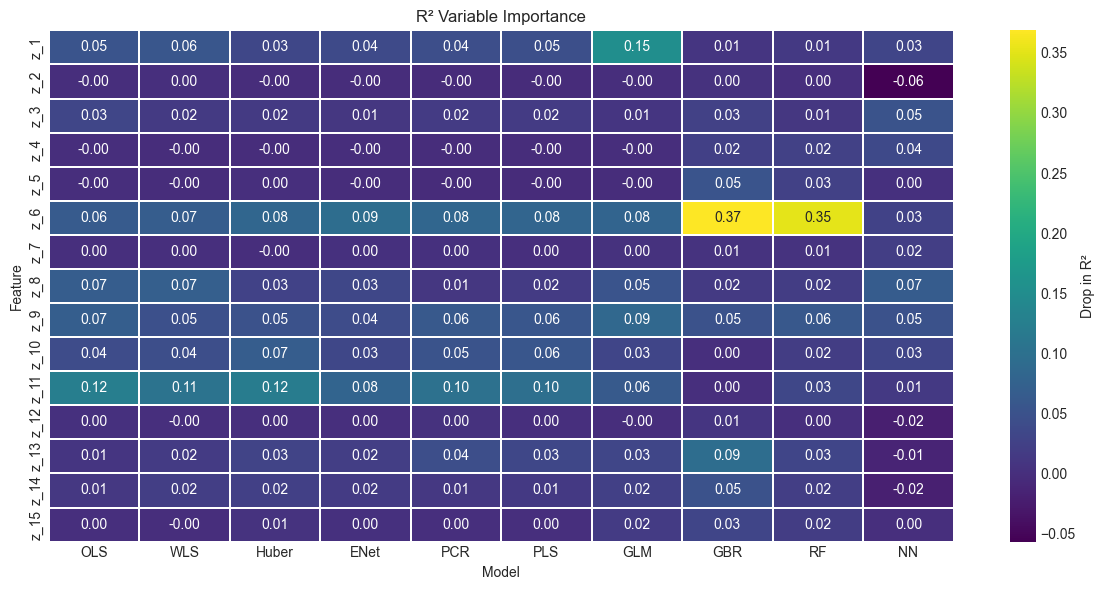

In [518]:
plt.figure(figsize=(12, 6))
sns.heatmap(
    var_imp_df,
    cmap="viridis",
    linewidths=0.3,
    annot=True,             # Werte ins Feld schreiben
    fmt=".2f",              # auf 2 Dezimalstellen runden
    cbar_kws={"label": "Drop in R²"}
)
plt.title("R² Variable Importance")
plt.xlabel("Model")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


### Interpretation of Feature Importance Bar Plot

The bar plot displays the total drop in out-of-sample $R^2$ summed across all models when each feature is removed. Features at the top contribute most to predictive accuracy. A higher bar indicates greater overall importance for return forecasting across models.


C:\Users\leven\AppData\Local\Temp\ipykernel_31624\1657823152.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


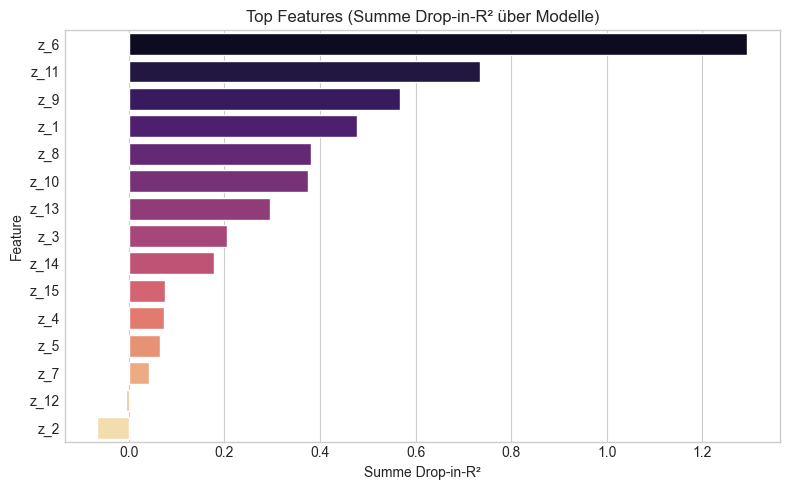

In [519]:
feature_total_importance = var_imp_df.sum(axis=1).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(
    x=feature_total_importance.values,
    y=feature_total_importance.index,
    palette="magma"
)
plt.title("Top Features (Summe Drop-in-R² über Modelle)")
plt.xlabel("Summe Drop-in-R²")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


### Interpretation of Model-Level Feature Utilization

The bar plot shows the total drop in $R^2$ for each model when all features are removed one at a time. Models with higher total drop-in-$R^2$ rely more heavily on the input features for prediction. Gradient Boosting and Random Forest exhibit the strongest feature dependence, while ElasticNet and PLS rely less on individual variables.


C:\Users\leven\AppData\Local\Temp\ipykernel_31624\37259231.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


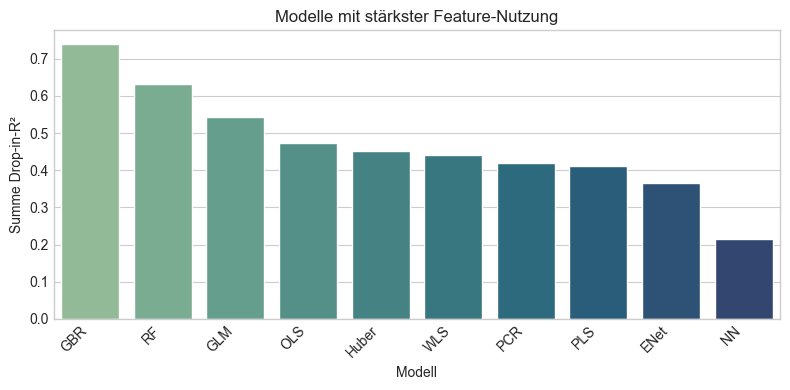

In [520]:
model_total_importance = var_imp_df.sum(axis=0).sort_values(ascending=False)

plt.figure(figsize=(8, 4))
sns.barplot(
    x=model_total_importance.index,
    y=model_total_importance.values,
    palette="crest"
)
plt.title("Modelle mit stärkster Feature-Nutzung")
plt.ylabel("Summe Drop-in-R²")
plt.xlabel("Modell")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


### Feature Importance via Sum of Squared Deviations (SSD)

This method quantifies feature importance by measuring the increase in prediction error—specifically, the **sum of squared deviations (SSD)**—when each feature is removed from the model input at test time. For each model, we compute:

$$
\text{SSD}_{\text{full}} = \sum_{i=1}^{n} (y_i - \hat{y}_i)^2
$$

Then, for each feature $j$, we modify the test set by setting feature $j$ to zero and recompute the SSD:

$$
\text{SSD}_{-j} = \sum_{i=1}^{n} (y_i - \hat{y}_{i,-j})^2
$$

The importance of feature $j$ is defined as the difference:

$$
\Delta \text{SSD}_j = \text{SSD}_{-j} - \text{SSD}_{\text{full}}
$$

A larger $\Delta \text{SSD}_j$ indicates that the model’s performance degrades significantly when feature $j$ is removed, implying higher predictive relevance of that feature.

The result is a feature-by-model importance matrix, where each entry captures how sensitive a model's predictions are to a specific input feature.

This SSD-based approach is model-agnostic and complements $R^2$-based drop-in importance by focusing on absolute error increases rather than variance explained. In financial forecasting, such diagnostics are valuable for identifying economically meaningful variables that materially affect model accuracy.


In [521]:
# SSD

# List feature names
features = [col for col in combined_data.columns if col.startswith('z_')]

# SSD Importance Dictionary
ssd_imp = {}

for name, fn in predict_fn.items():
    # predictions with all features
    y_full = fn(X_test)
    ssd_full = np.sum((y_test - y_full) ** 2)

    deviations = []

    for j in range(X_test.shape[1]):
        X_mod = X_test.copy()
        X_mod[:, j] = 0  # setze ein Feature auf 0
        y_drop = fn(X_mod)
        ssd_drop = np.sum((y_test - y_drop) ** 2)

        delta_ssd = ssd_drop - ssd_full
        deviations.append(delta_ssd)

    ssd_imp[name] = deviations

# DataFrame: Features × Models
ssd_imp_df = pd.DataFrame(ssd_imp, index=features)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


### Interpretation of SSD-Based Feature Importance Heatmap

The heatmap shows the increase in prediction error, measured by the sum of squared deviations (SSD), when each feature is removed from the test set. Each cell quantifies how much a model’s performance worsens when a specific feature is excluded. Brighter values indicate greater sensitivity to that feature.

For example, feature $z_6$ leads to large SSD increases in tree-based models (GBR, RF), suggesting strong dependence. Similarly, $z_{11}$ appears important across several models.

However, since the underlying data is synthetic and based on random combinations of characteristics and macroeconomic inputs, the resulting importances are not economically interpretable. If the features had real-world meaning (e.g., value, momentum, inflation), such results could guide investors and researchers in understanding which variables most affect return predictability.


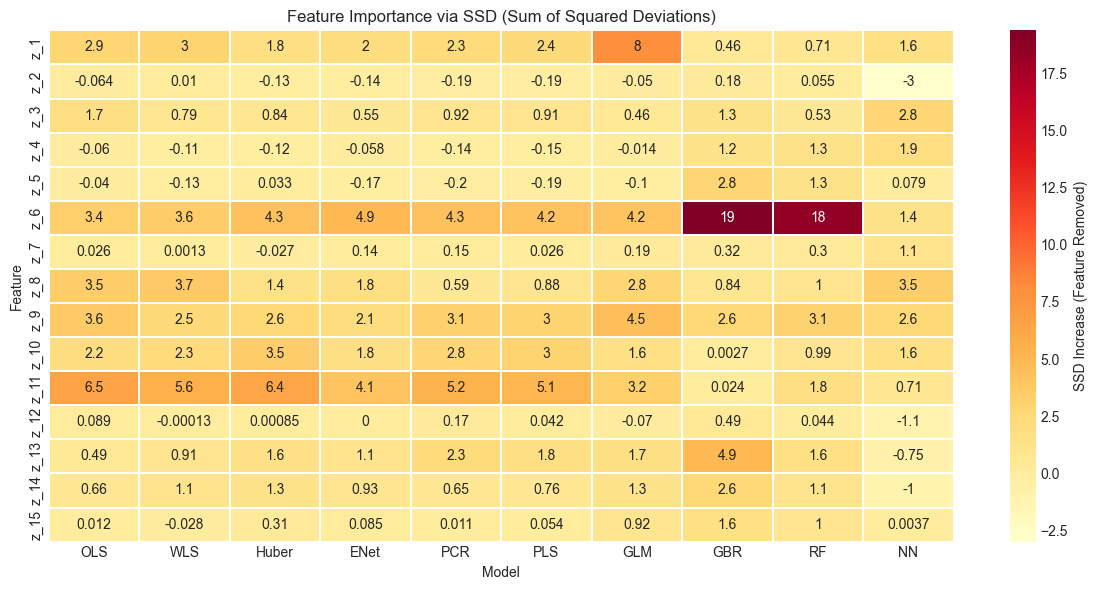

In [522]:
plt.figure(figsize=(12, 6))
sns.heatmap(
    ssd_imp_df,
    cmap="YlOrRd",
    linewidths=0.3,
    annot=True,
    cbar_kws={"label": "SSD Increase (Feature Removed)"}
)
plt.title("Feature Importance via SSD (Sum of Squared Deviations)")
plt.xlabel("Model")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


---
---
### Explanation of Decile Assignment and Data Preparation

The function `assign_decile(x)` assigns each value in the input series $x$ to a decile group (1–10) based on its rank. If all values are identical, it returns decile 1 for all entries. Otherwise, it uses the `rank` of each element and computes:

$$
\text{decile} = \left\lceil \frac{\text{rank} \cdot 10}{n} \right\rceil
$$

This allows observations to be grouped into ten equally sized bins for portfolio analysis.

The helper function `safe_div(x, y)` performs division while avoiding division-by-zero errors, returning `NaN` if the denominator is zero.

In the final step, the code splits the full dataset into training and test indices using `train_test_split`, preserving the test set for evaluating decile-based performance later. The resulting `ri_t_df_test` DataFrame contains the test portion of the return data, with the index reset for clean processing.


In [523]:


def assign_decile(x):
    """Weist Werte basierend auf Rang in Deciles (1–10) ein."""
    if x.nunique() == 1:
        return pd.Series(1, index=x.index)
    else:
        ranks = x.rank(method='first')
        n = len(x)
        deciles = np.ceil((ranks * 10) / n).astype(int)
        return deciles

def safe_div(x, y):
    return x / y if y != 0 else np.nan


indices = np.arange(len(ri_t_flattened))
_, test_indices = train_test_split(indices, test_size=0.3, random_state=42)
ri_t_df_test = ri_t_df.iloc[test_indices].reset_index(drop=True)

### Decile Portfolio Analysis and Sharpe Ratio Evaluation

This code performs **decile portfolio analysis** for each predictive model, a common technique in empirical asset pricing to evaluate how well a model ranks assets by expected return.

1. **Predictions and Decile Assignment**:
   For each model, the predicted returns (`Pred`) on the test set are used to sort stocks into **deciles** within each month using `assign_decile`. Decile 1 contains the lowest predicted returns, and Decile 10 the highest.

2. **Monthly Decile Averages**:
   For each decile in each month, the code computes the average predicted return (`Mean_Pred`) and the realized excess return (`Mean_Actual`).

3. **Sharpe Ratios**:
   Across months, it calculates the mean and standard deviation of both predicted and actual returns per decile. From this, it computes predicted and actual **Sharpe Ratios**:

   $$
   SR = \frac{\text{Mean Return}}{\text{Standard Deviation}}
   $$

4. **Long-Short Strategy**:
   The top and bottom deciles (New_Decile 10 and 1) are interpreted as long and short portfolios. The code computes the **long-short spread** in mean return and its volatility, then derives the **Sharpe Ratio of the long-short portfolio** (both predicted and actual).

#### Purpose in Asset Return Forecasting

This method assesses not just point prediction accuracy, but whether the model correctly **ranks assets** by future performance. High Sharpe Ratios in the long-short portfolios suggest the model successfully separates "winner" and "loser" stocks. This is crucial in finance, where return ranking drives strategy profitability more than return magnitude prediction.


In [524]:
results = {}

for model_name, predict in predict_fn.items():
    df_model = ri_t_df_test.copy()
    df_model["Pred"] = predict(X_test).flatten()

    
    df_model["Decile"] = df_model.groupby("Month")["Pred"].transform(assign_decile)

    
    monthly_decile = df_model.groupby(["Month", "Decile"], as_index=False).agg({
        "Pred": "mean",
        "Excess_Return": "mean"
    }).rename(columns={"Pred": "Mean_Pred", "Excess_Return": "Mean_Actual"})

    
    decile_stats = monthly_decile.groupby("Decile").agg({
        "Mean_Pred": ["mean", "std"],
        "Mean_Actual": ["mean", "std"]
    }).reset_index()

    decile_stats.columns = ["Decile", "Mean_Pred", "SD_Pred", "Mean_Actual", "SD_Actual"]
    decile_stats["SR_Pred"] = decile_stats.apply(lambda row: safe_div(row["Mean_Pred"], row["SD_Pred"]), axis=1)
    decile_stats["SR_Actual"] = decile_stats.apply(lambda row: safe_div(row["Mean_Actual"], row["SD_Actual"]), axis=1)

    
    decile_stats = decile_stats.sort_values(by="Mean_Pred").reset_index(drop=True)
    decile_stats["New_Decile"] = decile_stats.index + 1

    
    min_d, max_d = decile_stats["New_Decile"].min(), decile_stats["New_Decile"].max()

    long_short_pred = (
        decile_stats.loc[decile_stats["New_Decile"] == max_d, "Mean_Pred"].values[0] -
        decile_stats.loc[decile_stats["New_Decile"] == min_d, "Mean_Pred"].values[0]
    )
    long_short_actual = (
        decile_stats.loc[decile_stats["New_Decile"] == max_d, "Mean_Actual"].values[0] -
        decile_stats.loc[decile_stats["New_Decile"] == min_d, "Mean_Actual"].values[0]
    )

    sd_pred = np.sqrt(
        decile_stats.loc[decile_stats["New_Decile"] == max_d, "SD_Pred"].values[0]**2 +
        decile_stats.loc[decile_stats["New_Decile"] == min_d, "SD_Pred"].values[0]**2
    )
    sd_actual = np.sqrt(
        decile_stats.loc[decile_stats["New_Decile"] == max_d, "SD_Actual"].values[0]**2 +
        decile_stats.loc[decile_stats["New_Decile"] == min_d, "SD_Actual"].values[0]**2
    )

    ls_sr_pred = safe_div(long_short_pred, sd_pred)
    ls_sr_actual = safe_div(long_short_actual, sd_actual)

    results[model_name] = {
        "decile_stats": decile_stats,
        "long_short_SR_pred": ls_sr_pred,
        "long_short_SR_actual": ls_sr_actual
    }


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


### Interpretation of Long–Short Sharpe Ratios

The table compares each model's ability to form profitable long–short portfolios based on predicted versus realized Sharpe Ratios. The **Long–Short SR Pred** column measures the Sharpe Ratio implied by the model's ranking, while **Long–Short SR Actual** shows the Sharpe Ratio of realized returns for the corresponding decile spread.

In this synthetic setup, most models—especially linear ones like OLS, PCR, and PLS—yield identical actual Sharpe Ratios, suggesting similar ranking accuracy. Tree-based models (RF, GBR) underperform, indicating poor ordering of expected returns. This reinforces that, in low-noise linear settings, simple models can be highly effective in return ranking.


In [525]:
comparison_df = pd.DataFrame({
    model: {
        "Long-Short SR Pred": vals["long_short_SR_pred"],
        "Long-Short SR Actual": vals["long_short_SR_actual"]
    }
    for model, vals in results.items()
}).T.sort_values(by="Long-Short SR Actual", ascending=False)

print(comparison_df)


       Long-Short SR Pred  Long-Short SR Actual
OLS              1.085647              1.233913
WLS              1.079277              1.233913
Huber            1.070390              1.233913
ENet             1.057076              1.233913
PCR              1.085970              1.233913
PLS              1.086100              1.233913
GLM              1.110037              1.087471
RF               0.979210              1.040295
NN               0.637110              0.733096
GBR              0.584057              0.507732


### Decile-Based Sharpe Ratio Evaluation

The bar plots show predicted and realized Sharpe Ratios across decile portfolios sorted by model forecasts. A well-functioning return model should assign higher predicted returns to deciles that subsequently realize higher Sharpe Ratios, ideally producing a monotonic pattern.

Comparing **Actual SR** and **Predicted SR** allows us to assess how well each model captures the risk-adjusted ranking of assets. This is especially useful in asset management, where constructing long–short portfolios based on predictive rankings requires stable return-risk profiles. Models with greater alignment between predicted and actual Sharpe Ratios are more reliable for real-world investment decisions.


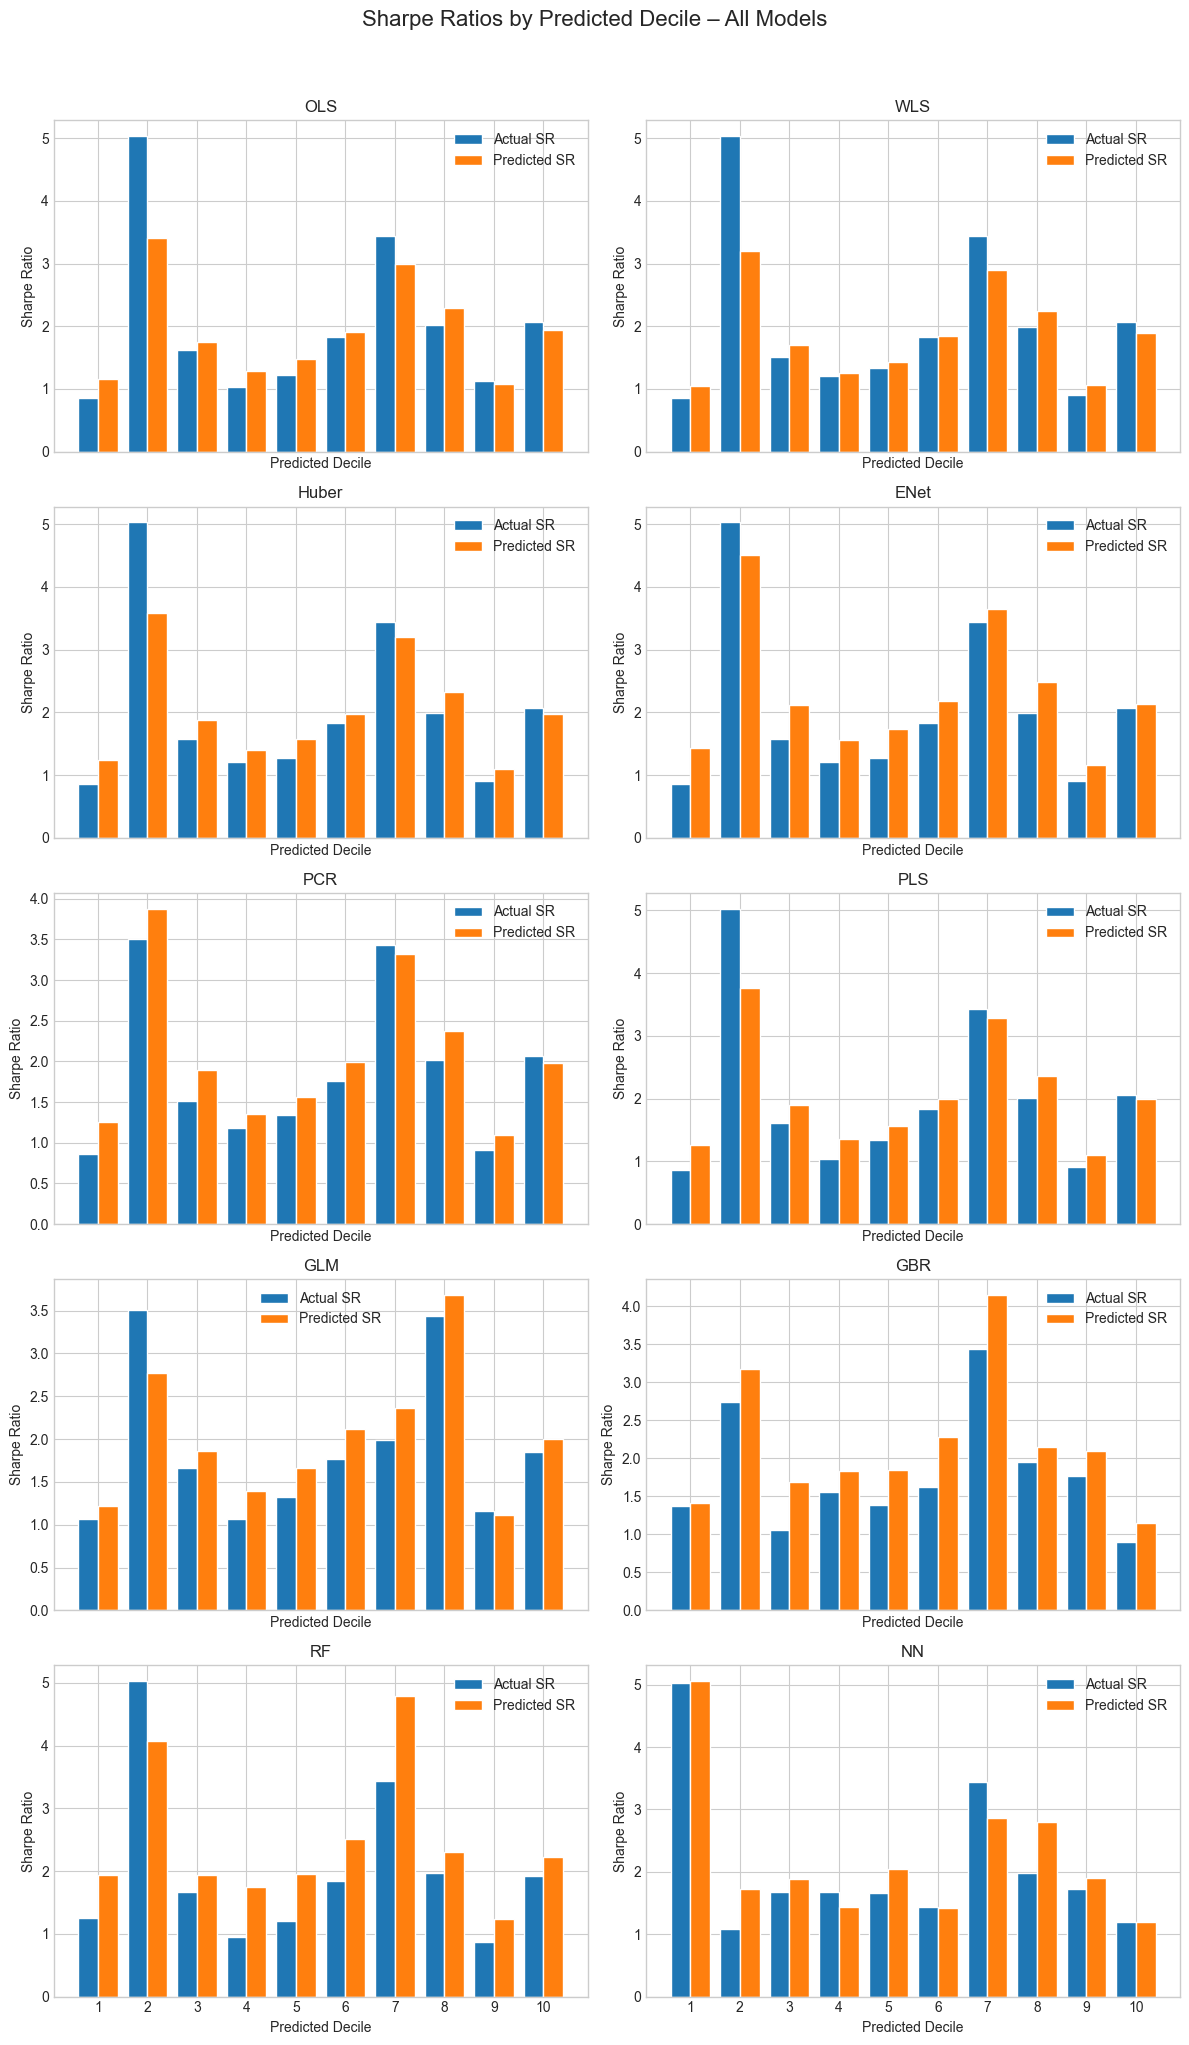

In [526]:

models = list(results.keys())


n_models = len(models)
n_cols = 2
n_rows = int(np.ceil(n_models / n_cols))


fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, n_rows * 4), sharex=True)
axes = axes.flatten()

for idx, model in enumerate(models):
    df = results[model]['decile_stats']
    ax = axes[idx]


    ax.bar(df['New_Decile'] - 0.2, df['SR_Actual'], width=0.4, label='Actual SR')
    ax.bar(df['New_Decile'] + 0.2, df['SR_Pred'], width=0.4, label='Predicted SR')
    
    ax.set_title(f"{model}")
    ax.set_xlabel("Predicted Decile")
    ax.set_ylabel("Sharpe Ratio")
    ax.set_xticks(df['New_Decile'])
    ax.grid(True)
    ax.legend()


for i in range(len(models), len(axes)):
    fig.delaxes(axes[i])

plt.suptitle("Sharpe Ratios by Predicted Decile – All Models", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()